# Volve Well 15/9-F-1 - Formation Evaluation

## Purpose

Notebook 1 asked whether the tool measurements could be trusted. 
Notebook 2 uses the QC output and answers the main question:

** what parts of well 15/9-F-1 appear clean, porous, water-bearing, or potentially hydrocarbon-bearing?**


### Notebook 2 workflow

```text
Load Notebook 1 QC output, confirm the working interval
    |
Choose the interpretation interval and flag Clean vs. Shalier zones
    |
Compute VSH, density porosity (PHID), and effective porosity (PHIE)
    |
Derive Rw and Rsh, then water saturation (Sw) - Archie/Simandoux selected per row by VSH
    |
Set cutoffs and build SAND_FLAG / RESERVOIR_FLAG / POSSIBLE_PAY_FLAG
    |
Summarise thickness and net pay, and test cutoff and matrix-density sensitivity
    |
Build the composite log panel and export results
```


## STEP 1: Load the QC output

Load `results/formation_evaluation_input.csv`,  from Notebook 1 with having the four required interpretation curves (GR, RHOB, NPHI, RT). 

In [1]:
# Cell 1: Import libraries and load Notebook 1's QC output

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("results")
INPUT_FILE = RESULTS_DIR / "formation_evaluation_input.csv"

IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

qc_output = pd.read_csv(INPUT_FILE)

fe_columns = [
    "DEPTH",
    "GR",
    "RHOB",
    "NPHI",
    "RT",
    "CALI",
    "BS",
    "DRHO",
    "DENSITY_RELIABILITY",
    "INTERPRETATION_READY_FLAG",
]

fe_df = qc_output[fe_columns].copy()

fe_df.head()


,DEPTH,GR,RHOB,NPHI,RT,CALI,BS,DRHO,DENSITY_RELIABILITY,INTERPRETATION_READY_FLAG
0,2605.0,30.4858,2.2693,0.2388,1.1330,8.7265,8.5,0.0583,Passed QC,True
1,2605.1,30.1558,2.3207,0.1986,1.0648,8.4844,8.5,0.0609,Passed QC,True
2,2605.2,32.5024,2.3443,0.1761,1.0538,8.4688,8.5,0.0608,Passed QC,True
3,2605.3,38.9391,2.3499,0.1691,1.0524,8.4688,8.5,0.0611,Passed QC,True
4,2605.4,53.1386,2.3484,0.1763,0.9913,8.4792,8.5,0.0623,Passed QC,True


## STEP 2 - Confirm the working interval

Before picking anything, check that what was loaded here matches what Notebook 1 reported.
Notebook 1's own summary (`results/README_notebook_1_summary.md`) states an
interpretation-ready depth range of **2605.0-3606.7 m** and **10,007** rows passing the
interpretation-ready screen. That count is out of a larger set of rows that simply have all
four required curves present (GR, RHOB, NPHI, RT) - Notebook 1 called this the
"formation-evaluation input" set, and it is larger than the ready-flag count because it also
keeps rows with a density QC caution.

In [2]:
# Cell 2: Row count, depth range, missing values, and interpretation-ready count

n_rows = len(fe_df)
top_depth = fe_df["DEPTH"].min()
base_depth = fe_df["DEPTH"].max()
missing_by_column = fe_df.isna().sum()
n_ready = int((fe_df["INTERPRETATION_READY_FLAG"] == True).sum())

print(f"Rows loaded: {n_rows:,}")
print(f"Top depth: {top_depth} m")
print(f"Base depth: {base_depth} m")
print()
print("Missing values per column:")
print(missing_by_column.to_string())
print()
print(f"Rows where INTERPRETATION_READY_FLAG is True: {n_ready:,}")


Rows loaded: 10,018
Top depth: 2605.0 m
Base depth: 3606.7 m

Missing values per column:
DEPTH                        0
GR                           0
RHOB                         0
NPHI                         0
RT                           0
CALI                         0
BS                           0
DRHO                         0
DENSITY_RELIABILITY          0
INTERPRETATION_READY_FLAG    0

Rows where INTERPRETATION_READY_FLAG is True: 10,007


In [3]:
# Cell 3: Flag clearly if these numbers do not match the Notebook 1 expectation

expected_top = 2605.0
expected_base = 3606.7
expected_ready = 10007

checks = pd.DataFrame(
    {
        "CHECK": [
            "Top depth (m)",
            "Base depth (m)",
            "Interpretation-ready rows",
        ],
        "EXPECTED_FROM_NOTEBOOK_1": [expected_top, expected_base, expected_ready],
        "ACTUAL_HERE": [top_depth, base_depth, n_ready],
    }
)
checks["MATCH"] = checks["EXPECTED_FROM_NOTEBOOK_1"] == checks["ACTUAL_HERE"]

print(checks.to_string(index=False))

if checks["MATCH"].all():
    print("\nAll figures match Notebook 1's reported QC output. Safe to proceed.")
else:
    print("\nWARNING: at least one figure differs from Notebook 1 - stop and investigate before proceeding.")


                    CHECK  EXPECTED_FROM_NOTEBOOK_1  ACTUAL_HERE  MATCH
            Top depth (m)                    2605.0       2605.0   True
           Base depth (m)                    3606.7       3606.7   True
Interpretation-ready rows                   10007.0      10007.0   True

All figures match Notebook 1's reported QC output. Safe to proceed.


## STEP 3 - Choose the interpretation interval

The full 2,605.0-3,606.7 m range is not treated as "reservoir" by default. There are no
formation tops in this LAS file, so no formation name (e.g. "Hugin") is assigned here without
an independent source - the interval below is described only by depth and log character.

To find a defensible sub-interval, the interpretation-ready rows are grouped into 25 m depth
bins and the mean GR, RT, RHOB and NPHI are compared bin by bin. This is a plain look at log
character: where does GR step down to a cleaner baseline, where does RT rise above the
surrounding background, and where do RHOB/NPHI both have real coverage?

In [4]:
# Cell 4: Bin the interpretation-ready rows by depth and look at log character

ready_df = fe_df.loc[fe_df["INTERPRETATION_READY_FLAG"] == True].copy()

ready_df["DEPTH_BIN"] = (ready_df["DEPTH"] // 25 * 25).astype(int)

character_summary = ready_df.groupby("DEPTH_BIN").agg(
    N_ROWS=("DEPTH", "size"),
    GR_MEAN=("GR", "mean"),
    GR_MIN=("GR", "min"),
    RHOB_MEAN=("RHOB", "mean"),
    NPHI_MEAN=("NPHI", "mean"),
    RT_MEAN=("RT", "mean"),
    RT_MAX=("RT", "max"),
).round(2)

character_summary


,N_ROWS,GR_MEAN,GR_MIN,RHOB_MEAN,NPHI_MEAN,RT_MEAN,RT_MAX
DEPTH_BIN,,,,,,,
2600,198,59.75,24.59,2.33,0.33,0.89,4.11
2625,250,37.55,30.02,2.25,0.25,0.48,1.08
2650,250,38.18,28.11,2.24,0.25,0.49,2.34
2675,250,44.01,23.33,2.23,0.29,0.56,3.33
2700,250,31.32,25.88,2.20,0.26,0.50,4.13
2725,245,42.48,25.07,2.34,0.25,3.44,197.79
2750,250,26.76,7.40,2.27,0.24,0.70,3.92
2775,250,9.95,1.96,2.46,0.17,1.78,4.30
2800,250,3.05,1.24,2.48,0.13,2.13,5.66


Reading down this table: GR sits in the 30-60 API range from the top of the interval
(2,605 m) down to about 2,750 m, then steps down to single digits from roughly 2,775 m to
about 3,250 m, before kicking sharply back up past 200-300 API around 3,270-3,310 m and
settling into a 40-100 API baseline for the remainder of the well. RT follows the same shape
in reverse: it is below 1 ohm.m through the upper shale-like section, rises to a multi-ohm.m
range through the low-GR section, and drops back down below the hot zone. RHOB and NPHI have
full coverage across the low-GR section. The next cell narrows the two transitions to find
where the GR break is sharpest.

In [5]:
# Cell 5: Narrow the top and base transitions using 5 m bins

ready_df["DEPTH_BIN_FINE"] = (ready_df["DEPTH"] // 5 * 5).round(1)

top_transition = ready_df.loc[
    (ready_df["DEPTH"] >= 2755) & (ready_df["DEPTH"] <= 2790)
]
base_transition = ready_df.loc[
    (ready_df["DEPTH"] >= 3245) & (ready_df["DEPTH"] <= 3275)
]

top_transition_summary = top_transition.groupby("DEPTH_BIN_FINE").agg(
    N_ROWS=("DEPTH", "size"),
    GR_MEAN=("GR", "mean"),
    GR_MIN=("GR", "min"),
    GR_MAX=("GR", "max"),
    RT_MEAN=("RT", "mean"),
).round(2)

base_transition_summary = base_transition.groupby("DEPTH_BIN_FINE").agg(
    N_ROWS=("DEPTH", "size"),
    GR_MEAN=("GR", "mean"),
    GR_MIN=("GR", "min"),
    GR_MAX=("GR", "max"),
    RT_MEAN=("RT", "mean"),
).round(2)

print("Top transition, 2755-2790 m:")
print(top_transition_summary.to_string())
print()
print("Base transition, 3245-3275 m:")
print(base_transition_summary.to_string())


Top transition, 2755-2790 m:
                N_ROWS  GR_MEAN  GR_MIN  GR_MAX  RT_MEAN
DEPTH_BIN_FINE                                          
2755.0              50    27.80   24.86   34.43     0.37
2760.0              50    31.52   24.67   54.39     0.39
2765.0              50    33.42    7.40   70.64     1.07
2770.0              50    10.91    7.81   17.72     1.31
2775.0              50    11.69    6.61   16.52     1.34
2780.0              50    17.16   13.51   25.83     1.70
2785.0              50    12.99    3.42   27.54     2.65
2790.0               1     6.86    6.86    6.86     3.46

Base transition, 3245-3275 m:
                N_ROWS  GR_MEAN  GR_MIN  GR_MAX  RT_MEAN
DEPTH_BIN_FINE                                          
3245.0              50    56.46   49.02   71.55     2.61
3250.0              50    67.11   25.79  104.01     2.06
3255.0              50    43.54   27.22   63.78     2.04
3260.0              50    65.95   46.73   88.54     2.15
3265.0              50    68

In the top transition, the GR mean drops from 33.42 API (2,765 m bin) to 10.91 API
(2,770 m bin) and stays below about 17 API from there down - so **2,770.0 m** is used as the
top of the cleaner interval. In the base transition, GR is still a shale-like 65-69 API mean
through 3,260-3,265 m, then jumps to a mean of 248.93 API (max 296.96 API) in the 3,270 m bin
- an unmistakable hot marker bed - so **3,270.0 m** is used as the base.

In [6]:
# Cell 6: Set the interpretation interval and summarise it against the bounding intervals

INTERPRETATION_TOP_M = 2770.0
INTERPRETATION_BASE_M = 3270.0

interval_df = ready_df.loc[
    (ready_df["DEPTH"] >= INTERPRETATION_TOP_M) & (ready_df["DEPTH"] <= INTERPRETATION_BASE_M)
]
above_df = ready_df.loc[
    (ready_df["DEPTH"] >= 2605.0) & (ready_df["DEPTH"] < INTERPRETATION_TOP_M)
]
below_df = ready_df.loc[
    (ready_df["DEPTH"] > INTERPRETATION_BASE_M) & (ready_df["DEPTH"] <= 3606.7)
]
below_immediate_df = ready_df.loc[
    (ready_df["DEPTH"] > INTERPRETATION_BASE_M) & (ready_df["DEPTH"] <= INTERPRETATION_BASE_M + 100)
]

interval_vs_bounds = pd.DataFrame(
    {
        "SEGMENT": [
            f"Above ({2605.0}-{INTERPRETATION_TOP_M} m)",
            f"Chosen interval ({INTERPRETATION_TOP_M}-{INTERPRETATION_BASE_M} m)",
            f"Below, immediate 100 m ({INTERPRETATION_BASE_M}-{INTERPRETATION_BASE_M + 100} m)",
            f"Below, full remainder ({INTERPRETATION_BASE_M}-3606.7 m)",
        ],
        "N_ROWS": [len(above_df), len(interval_df), len(below_immediate_df), len(below_df)],
        "GR_MEAN": [
            above_df["GR"].mean(),
            interval_df["GR"].mean(),
            below_immediate_df["GR"].mean(),
            below_df["GR"].mean(),
        ],
        "GR_MEDIAN": [
            above_df["GR"].median(),
            interval_df["GR"].median(),
            below_immediate_df["GR"].median(),
            below_df["GR"].median(),
        ],
        "RT_MEAN": [
            above_df["RT"].mean(),
            interval_df["RT"].mean(),
            below_immediate_df["RT"].mean(),
            below_df["RT"].mean(),
        ],
        "RT_MAX": [
            above_df["RT"].max(),
            interval_df["RT"].max(),
            below_immediate_df["RT"].max(),
            below_df["RT"].max(),
        ],
        "RHOB_MEAN": [
            above_df["RHOB"].mean(),
            interval_df["RHOB"].mean(),
            below_immediate_df["RHOB"].mean(),
            below_df["RHOB"].mean(),
        ],
        "NPHI_MEAN": [
            above_df["NPHI"].mean(),
            interval_df["NPHI"].mean(),
            below_immediate_df["NPHI"].mean(),
            below_df["NPHI"].mean(),
        ],
    }
).round(2)

rhob_nphi_coverage = interval_df[["RHOB", "NPHI"]].notna().sum()

print(interval_vs_bounds.to_string(index=False))
print()
print(f"RHOB/NPHI coverage inside the chosen interval: {rhob_nphi_coverage.to_dict()} out of {len(interval_df):,} rows")


                                 SEGMENT  N_ROWS  GR_MEAN  GR_MEDIAN  RT_MEAN  RT_MAX  RHOB_MEAN  NPHI_MEAN
                 Above (2605.0-2770.0 m)    1643    40.26      33.26     0.99  197.79       2.26       0.27
       Chosen interval (2770.0-3270.0 m)    5001    20.44      11.40     3.95   16.77       2.55       0.12
Below, immediate 100 m (3270.0-3370.0 m)    1000   166.81     122.09     2.52   19.72       2.37       0.30
 Below, full remainder (3270.0-3606.7 m)    3363    96.71      57.12     1.88   19.72       2.48       0.20

RHOB/NPHI coverage inside the chosen interval: {'RHOB': 5001, 'NPHI': 5001} out of 5,001 rows


### Interval chosen

**INTERPRETATION_TOP_M = 2,770.0 m**
**INTERPRETATION_BASE_M = 3,270.0 m**
(5,001 interpretation-ready rows fall inside this interval)

**Reasoning:** Inside 2,770.0-3,270.0 m, GR drops to a mean of 20.4 API (median 11.4 API)
against a bounding mean of 40.3 API immediately above and 166.8 API immediately below (the
3,270-3,370 m hot marker), while RT simultaneously rises to a mean of 3.95 ohm.m (max 16.77
ohm.m) versus background means of 0.99 ohm.m above and 2.52 ohm.m in that same immediate
zone below, and RHOB/NPHI both have complete (5,001/5,001) coverage across the interval -
together pointing to a cleaner, more resistive, fully-logged rock package sitting between two
shalier, lower-resistivity zones.

## Follow-up check - possible shalier sub-zone inside 3,100-3,270 m

Before finalizing the interval, look at GR and RT in 5 m bins across 3,100-3,270 m - the
lower part of the candidate interval - to check for a distinct shalier sub-zone, particularly
around 3,150-3,260 m. `INTERPRETATION_TOP_M` and `INTERPRETATION_BASE_M` are **not** changed
in this step; this is a check of internal structure only.

In [7]:
# Cell 7: GR and RT in 5 m bins across 3,100-3,270 m

lower_zone = ready_df.loc[
    (ready_df["DEPTH"] >= 3100) & (ready_df["DEPTH"] <= 3270)
]

lower_zone_summary = lower_zone.groupby("DEPTH_BIN_FINE").agg(
    N_ROWS=("DEPTH", "size"),
    GR_MEAN=("GR", "mean"),
    GR_MIN=("GR", "min"),
    GR_MAX=("GR", "max"),
    RT_MEAN=("RT", "mean"),
    RT_MAX=("RT", "max"),
    RHOB_MEAN=("RHOB", "mean"),
    NPHI_MEAN=("NPHI", "mean"),
).round(2)

lower_zone_summary


,N_ROWS,GR_MEAN,GR_MIN,GR_MAX,RT_MEAN,RT_MAX,RHOB_MEAN,NPHI_MEAN
DEPTH_BIN_FINE,,,,,,,,
3100.0,50,20.73,12.29,34.83,7.02,9.27,2.60,0.08
3105.0,50,34.87,25.62,44.39,3.46,4.95,2.56,0.13
3110.0,50,35.13,28.44,44.70,3.18,3.74,2.55,0.12
3115.0,50,38.70,27.39,48.27,2.75,3.55,2.55,0.14
3120.0,50,30.70,22.68,40.30,2.83,3.41,2.57,0.13
3125.0,50,26.27,20.38,31.43,3.35,3.73,2.59,0.11
3130.0,50,28.38,21.17,37.71,3.36,4.19,2.59,0.11
3135.0,50,24.46,17.65,29.84,4.00,4.68,2.59,0.09
3140.0,50,24.76,17.07,32.68,4.79,6.23,2.61,0.09


Reading this table: GR sits below 20 API only in the 3,100.0 m bin (a transitional bin -
still mixed, 12-34 API), then from about 3,105 m onward it settles into a consistently higher
30-60 API baseline all the way to the 3,270 m base of the candidate interval, with one brief
exception - a roughly 6 m thinner streak around 3,214-3,220 m where GR drops back to the low
20s and RT rises to 4.6-4.7 ohm.m, standing out from its immediate surroundings but far too
thin to be the main feature. The next cell quantifies the sub-zone against the cleaner rock
immediately above it.

In [8]:
# Cell 8: Quantify the shalier sub-zone against the cleaner rock above it

subzone_top, subzone_base = 3105.0, 3270.0

subzone_df = ready_df.loc[
    (ready_df["DEPTH"] >= subzone_top) & (ready_df["DEPTH"] <= subzone_base)
]
clean_zone_above_df = ready_df.loc[
    (ready_df["DEPTH"] >= INTERPRETATION_TOP_M) & (ready_df["DEPTH"] < subzone_top)
]

subzone_comparison = pd.DataFrame(
    {
        "SEGMENT": [
            f"Clean zone above ({INTERPRETATION_TOP_M}-{subzone_top} m)",
            f"Shalier sub-zone ({subzone_top}-{subzone_base} m)",
        ],
        "N_ROWS": [len(clean_zone_above_df), len(subzone_df)],
        "GR_MEAN": [clean_zone_above_df["GR"].mean(), subzone_df["GR"].mean()],
        "GR_MEDIAN": [clean_zone_above_df["GR"].median(), subzone_df["GR"].median()],
        "RT_MEAN": [clean_zone_above_df["RT"].mean(), subzone_df["RT"].mean()],
        "RT_MEDIAN": [clean_zone_above_df["RT"].median(), subzone_df["RT"].median()],
        "NPHI_MEAN": [clean_zone_above_df["NPHI"].mean(), subzone_df["NPHI"].mean()],
    }
).round(2)

print(subzone_comparison.to_string(index=False))
print()
print(
    f"Approximate shalier sub-zone: {subzone_top}-{subzone_base} m "
    f"(n={len(subzone_df):,} rows)"
)
print(f"  Mean GR: {subzone_df['GR'].mean():.1f} API (median {subzone_df['GR'].median():.1f} API)")
print(f"  Mean RT: {subzone_df['RT'].mean():.2f} ohm.m (median {subzone_df['RT'].median():.2f} ohm.m)")
print(
    "NOTE: INTERPRETATION_TOP_M and INTERPRETATION_BASE_M are unchanged "
    f"({INTERPRETATION_TOP_M} m / {INTERPRETATION_BASE_M} m) - this sub-zone sits inside "
    "the existing candidate interval and is not carved out as a separate interval; it is "
    "flagged instead (see ZONE_CHARACTER, below)."
)


                           SEGMENT  N_ROWS  GR_MEAN  GR_MEDIAN  RT_MEAN  RT_MEDIAN  NPHI_MEAN
Clean zone above (2770.0-3105.0 m)    3350     9.20       8.00     4.50       4.02       0.10
Shalier sub-zone (3105.0-3270.0 m)    1651    43.24      41.23     2.84       2.67       0.15

Approximate shalier sub-zone: 3105.0-3270.0 m (n=1,651 rows)
  Mean GR: 43.2 API (median 41.2 API)
  Mean RT: 2.84 ohm.m (median 2.67 ohm.m)
NOTE: INTERPRETATION_TOP_M and INTERPRETATION_BASE_M are unchanged (2770.0 m / 3270.0 m) - this sub-zone sits inside the existing candidate interval and is not carved out as a separate interval; it is flagged instead (see ZONE_CHARACTER, below).


### Sub-zone finding (interval boundaries unchanged)

A distinct shalier sub-zone is visible from approximately **3,105 m to 3,270 m** - i.e. it
occupies the lower part of the candidate interval, running down to the interval's existing
base rather than sitting only within 3,150-3,260 m as originally guessed. Within it, mean GR
is 43.2 API (median 41.2 API) versus 9.2 API in the cleaner rock immediately above
(2,770-3,105 m), and mean RT is 2.84 ohm.m versus 4.5 ohm.m above - a clear drop in
resistivity alongside the GR increase, consistent with more shale and less pay-quality rock.
A thin (~6 m) cleaner streak interrupts it around 3,214-3,220 m (GR briefly near 20-26 API,
RT briefly 4.6-4.7 ohm.m) but is too thin to change the overall read.

`INTERPRETATION_TOP_M` (2,770.0 m) and `INTERPRETATION_BASE_M` (3,270.0 m) are unchanged. The
sub-zone is kept inside one interval with an internal flag rather than carved out as a second,
separate interval - see `ZONE_CHARACTER` next.

## STEP 4 - Zone-character flag

The interpretation interval is now confirmed and final:

**INTERPRETATION_TOP_M = 2,770.0 m**
**INTERPRETATION_BASE_M = 3,270.0 m**

These boundaries are not revisited again in this notebook. Within this interval, the
follow-up check above found a real GR/RT break at 3,105.0 m - mean GR of 9.2 API above versus
43.2 API below, with RT dropping from a mean of 4.50 ohm.m to 2.84 ohm.m. A `ZONE_CHARACTER`
column is added here to carry that break forward: it describes geology by depth, and groups
the thickness tables and composite log panel later. **It does not decide which
water-saturation model applies** - that choice is made per row, by VSH, in Step 10C. No Sw is
calculated in this step - only the flag is added and confirmed.

In [9]:
# Cell 9: Build the confirmed interpretation-interval working set and add ZONE_CHARACTER

ZONE_SPLIT_DEPTH_M = 3105.0

interpretation_interval_df = fe_df.loc[
    (fe_df["DEPTH"] >= INTERPRETATION_TOP_M) & (fe_df["DEPTH"] <= INTERPRETATION_BASE_M)
].copy()

interpretation_interval_df["ZONE_CHARACTER"] = np.where(
    interpretation_interval_df["DEPTH"] < ZONE_SPLIT_DEPTH_M,
    "Clean",
    "Shalier",
)

zone_row_counts = interpretation_interval_df["ZONE_CHARACTER"].value_counts()

print(f"Rows in the interpretation interval ({INTERPRETATION_TOP_M}-{INTERPRETATION_BASE_M} m): {len(interpretation_interval_df):,}")
print()
print("Row counts per zone:")
print(zone_row_counts.to_string())


Rows in the interpretation interval (2770.0-3270.0 m): 5,001

Row counts per zone:
ZONE_CHARACTER
Clean      3350
Shalier    1651


In [10]:
# Cell 10: Confirm the flag reproduces the GR/RT break already found

zone_check = interpretation_interval_df.groupby("ZONE_CHARACTER").agg(
    N_ROWS=("DEPTH", "size"),
    DEPTH_MIN=("DEPTH", "min"),
    DEPTH_MAX=("DEPTH", "max"),
    GR_MEAN=("GR", "mean"),
    RT_MEAN=("RT", "mean"),
).round(2)

zone_check


,N_ROWS,DEPTH_MIN,DEPTH_MAX,GR_MEAN,RT_MEAN
ZONE_CHARACTER,,,,,
Clean,3350,2770.0,3104.9,9.20,4.50
Shalier,1651,3105.0,3270.0,43.24,2.84


## STEP 5 - Gamma-ray index

`IGR` is calculated from GR using the two endpoints of the gamma-ray response:

```text
IGR = (GR - GR_clean) / (GR_shale - GR_clean), clipped to [0, 1]
```

`GR_clean` and `GR_shale` are taken as the 5th and 95th percentiles of GR **within the
interpretation interval only** (2,770.0-3,270.0 m across both the `Clean` and `Shalier`
zones), not the whole well. The interval already excludes the hot marker bed just below
3,270 m, so anchoring the endpoints to the interval's own GR range avoids that extreme value
distorting the shale endpoint.

In [11]:
# Cell 11: Derive GR_clean / GR_shale from the interval and calculate IGR

GR_clean = interpretation_interval_df["GR"].quantile(0.05)
GR_shale = interpretation_interval_df["GR"].quantile(0.95)

igr_raw = (
    (interpretation_interval_df["GR"] - GR_clean)
    / (GR_shale - GR_clean)
)

interpretation_interval_df["IGR"] = igr_raw.clip(lower=0, upper=1)

n_clipped_low = int((igr_raw < 0).sum())
n_clipped_high = int((igr_raw > 1).sum())

print(f"GR_clean (5th percentile, within {INTERPRETATION_TOP_M}-{INTERPRETATION_BASE_M} m): {GR_clean:.2f} API")
print(f"GR_shale (95th percentile, within {INTERPRETATION_TOP_M}-{INTERPRETATION_BASE_M} m): {GR_shale:.2f} API")
print()
print(f"IGR summary: min={interpretation_interval_df['IGR'].min():.3f}, "
      f"mean={interpretation_interval_df['IGR'].mean():.3f}, "
      f"max={interpretation_interval_df['IGR'].max():.3f}")
print(f"Rows clipped to 0 (GR below GR_clean): {n_clipped_low:,}")
print(f"Rows clipped to 1 (GR above GR_shale): {n_clipped_high:,}")


GR_clean (5th percentile, within 2770.0-3270.0 m): 2.65 API
GR_shale (95th percentile, within 2770.0-3270.0 m): 58.43 API

IGR summary: min=0.000, mean=0.311, max=1.000
Rows clipped to 0 (GR below GR_clean): 250
Rows clipped to 1 (GR above GR_shale): 250


In [12]:
# Cell 12: IGR by zone, as a sanity check against the Clean/Shalier split

igr_by_zone = interpretation_interval_df.groupby("ZONE_CHARACTER").agg(
    N_ROWS=("IGR", "size"),
    IGR_MEAN=("IGR", "mean"),
    IGR_MEDIAN=("IGR", "median"),
).round(3)

igr_by_zone


,N_ROWS,IGR_MEAN,IGR_MEDIAN
ZONE_CHARACTER,,,
Clean,3350,0.118,0.096
Shalier,1651,0.702,0.692


## STEP 6 - Shale volume (VSH)

`VSH` is taken directly as `IGR` - a linear model, with no comparison against the
non-linear Larionov/Clavier/Steiber corrections at this stage. Plainly:

- **Low VSH** = cleaner rock (less shale/clay).
- **High VSH** = more shale/clay.
- GR also responds to radioactive minerals that are not clay (e.g. potassium feldspar,
  mica, some heavy minerals), so **VSH from GR is an estimate, not a direct clay
  measurement**.

In [13]:
# Cell 13: VSH as IGR directly, summarised by zone

interpretation_interval_df["VSH"] = interpretation_interval_df["IGR"]

vsh_by_zone = interpretation_interval_df.groupby("ZONE_CHARACTER")["VSH"].agg(
    ["mean", "median", "min", "max"]
).round(3)

print("VSH summary by zone:")
print(vsh_by_zone.to_string())
print()
print("VSH summary, whole interpretation interval:")
print(interpretation_interval_df["VSH"].describe().round(3).to_string())


VSH summary by zone:
                 mean  median    min  max
ZONE_CHARACTER                           
Clean           0.118   0.096  0.000  1.0
Shalier         0.702   0.692  0.258  1.0

VSH summary, whole interpretation interval:
count    5001.000
mean        0.311
std         0.316
min         0.000
25%         0.066
50%         0.157
75%         0.546
max         1.000


### Distribution shape

The next cell bins VSH into 0.05-wide steps across the whole interval and plots the two
zones on top of each other, to see whether the distribution is genuinely bimodal (two
separate clusters with a gap) or more continuous.

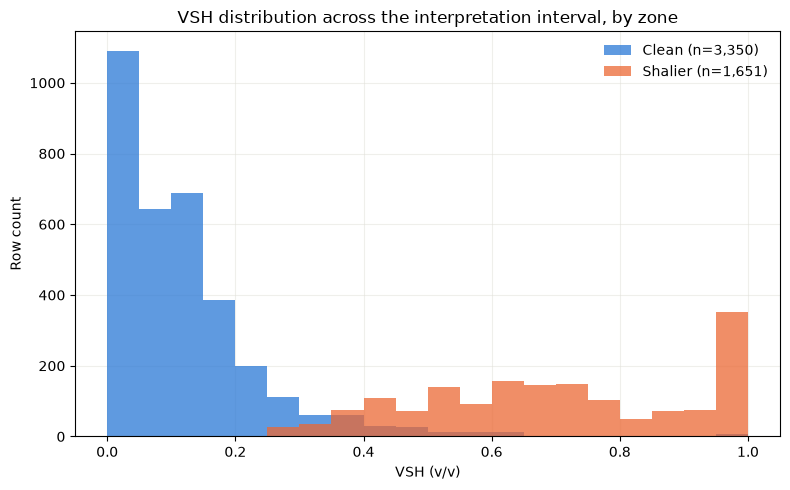

 BIN_START  BIN_END  N_ROWS
      0.00     0.05    1091
      0.05     0.10     643
      0.10     0.15     689
      0.15     0.20     387
      0.20     0.25     200
      0.25     0.30     137
      0.30     0.35      94
      0.35     0.40     135
      0.40     0.45     141
      0.45     0.50      99
      0.50     0.55     153
      0.55     0.60     106
      0.60     0.65     169
      0.65     0.70     148
      0.70     0.75     148
      0.75     0.80     104
      0.80     0.85      49
      0.85     0.90      74
      0.90     0.95      75
      0.95     1.00     359


In [14]:
# Cell 14: VSH distribution shape - histogram by zone

bin_edges = np.arange(0, 1.05, 0.05)

vsh_counts, _ = np.histogram(interpretation_interval_df["VSH"], bins=bin_edges)
vsh_bin_table = pd.DataFrame(
    {
        "BIN_START": bin_edges[:-1].round(2),
        "BIN_END": bin_edges[1:].round(2),
        "N_ROWS": vsh_counts,
    }
)

CLEAN_COLOR = "#2a78d6"
SHALIER_COLOR = "#eb6834"
GRIDLINE_COLOR = "#e1e0d9"

clean_vsh = interpretation_interval_df.loc[
    interpretation_interval_df["ZONE_CHARACTER"] == "Clean", "VSH"
]
shalier_vsh = interpretation_interval_df.loc[
    interpretation_interval_df["ZONE_CHARACTER"] == "Shalier", "VSH"
]

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    clean_vsh,
    bins=bin_edges,
    color=CLEAN_COLOR,
    alpha=0.75,
    label=f"Clean (n={len(clean_vsh):,})",
)
ax.hist(
    shalier_vsh,
    bins=bin_edges,
    color=SHALIER_COLOR,
    alpha=0.75,
    label=f"Shalier (n={len(shalier_vsh):,})",
)

ax.set_xlabel("VSH (v/v)")
ax.set_ylabel("Row count")
ax.set_title("VSH distribution across the interpretation interval, by zone")
ax.grid(alpha=0.5, color=GRIDLINE_COLOR)
ax.set_axisbelow(True)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "vsh_distribution_by_zone.png", dpi=300, bbox_inches="tight")
plt.show()

print(vsh_bin_table.to_string(index=False))


### Reading the distribution

Not cleanly bimodal - there is no empty gap separating two clusters. What is there:

- A **dominant low-end peak**: 1,091 of 5,001 rows (roughly 1 in 5) sit in the 0.00-0.05 bin
  alone, and counts fall off steadily from there through 0.10-0.25 - almost entirely `Clean`
  zone rows.
- A **shallow trough** through the middle: bins from 0.25 to 0.50 sit low and roughly flat
  (94-141 rows each) - the least common VSH values, and a mix of both zones' tails.
- A **broad, moderate shoulder** from about 0.50-0.75 (99-169 rows per bin) rather than a
  sharp second peak - this is where most `Shalier` zone rows sit, but spread out, not bunched.
- A **secondary peak at the very top**: 359 rows in 0.95-1.00, the second-largest single bin,
  driven by `Shalier` zone rows against the shale endpoint.

So VSH is right-skewed with two overlapping populations rather than two sharply separated
clusters: `Clean` zone rows pile up near 0 but still stretch as high as 1.0 (min 0.000, max
1.000), and `Shalier` zone rows range from 0.258 up to 1.000. The middle ground (roughly
0.25-0.5) is real, not empty, so a single VSH cutoff will inevitably split some continuous,
in-between rock one way or the other - there is no natural gap to place it in. The cutoff
itself is set next.

## VSH cutoff

`VSH_CUTOFF = 0.5` is set here as the standard industry sand/shale convention (a rock is
conventionally called "sand" below this line and "shale" above it), **not** because this
well's own VSH distribution shows a natural split at 0.5. As Step 6 already showed, the
distribution is right-skewed rather than cleanly bimodal, and 0.5 sits in one of its locally
lower-density stretches: only 99 of 5,001 rows fall in the 0.45-0.50 bin, versus 1,091 in
0.00-0.05 and 643 in 0.05-0.10 alone. So the cutoff is being chosen on physical convention,
with the data offering mild corroboration (a local low point, not a packed cluster) - not the
other way around. `SAND_FLAG` is not created yet; the cutoff is only defined here for later
use.

In [15]:
# Cell 15: Define the VSH cutoff (not yet applied)

VSH_CUTOFF = 0.5

rows_at_cutoff_bin = int(
    ((interpretation_interval_df["VSH"] >= 0.45) & (interpretation_interval_df["VSH"] < 0.50)).sum()
)
rows_low_end = int(
    ((interpretation_interval_df["VSH"] >= 0.00) & (interpretation_interval_df["VSH"] < 0.10)).sum()
)

print(f"VSH_CUTOFF set to {VSH_CUTOFF} (industry sand/shale convention).")
print(f"Rows in the 0.45-0.50 bin (near the cutoff): {rows_at_cutoff_bin:,}")
print(f"Rows in the 0.00-0.10 range (low end of the distribution): {rows_low_end:,}")
print("No SAND_FLAG created yet - the cutoff is defined only, not applied.")


VSH_CUTOFF set to 0.5 (industry sand/shale convention).
Rows in the 0.45-0.50 bin (near the cutoff): 99
Rows in the 0.00-0.10 range (low end of the distribution): 1,734
No SAND_FLAG created yet - the cutoff is defined only, not applied.


## STEP 7 - Density porosity (PHID)

```text
PHID = (matrix_density - RHOB) / (matrix_density - fluid_density)
```

**Assumption flagged for review:** `matrix_density = 2.65 g/cm3` (quartz) and
`fluid_density = 1.0 g/cm3` (fresh water) are both fixed constants here, not measured or
fitted from this well. They are reasonable defaults for a clean sandstone with a
water-based mud filtrate, but they are not verified against core, and if the true fluid in
the pore space is hydrocarbon-bearing mud filtrate or the matrix is not pure quartz, PHID
will be biased. This is not finalized silently - it is a stated assumption for review.

PHID is only calculated for rows where RHOB exists (in this interval, RHOB already has full
5,001/5,001 coverage, per Step 3's check - so the condition is satisfied trivially here, but
the code still checks it explicitly rather than assuming it). Both the raw and the clipped
version are kept: `PHID_RAW` (unclipped, can go negative or unrealistically high) and `PHID`
(clipped to 0-0.4, the physically plausible range for porosity) - so a reviewer can see what
the clip actually changed.

In [16]:
# Cell 16: Calculate PHID, flagging the matrix/fluid density assumption explicitly

MATRIX_DENSITY_G_CM3 = 2.65  # ASSUMPTION: quartz matrix - not verified against core for this well
FLUID_DENSITY_G_CM3 = 1.0    # ASSUMPTION: fresh water - not verified against mud/formation fluid data

print("ASSUMPTION FLAGGED FOR REVIEW:")
print(f"  matrix_density = {MATRIX_DENSITY_G_CM3} g/cm3 (quartz)")
print(f"  fluid_density  = {FLUID_DENSITY_G_CM3} g/cm3 (fresh water)")
print("  Neither value has been verified against core or fluid-sample data for this well.")
print()

rhob_available = interpretation_interval_df["RHOB"].notna()

phid_raw = (
    (MATRIX_DENSITY_G_CM3 - interpretation_interval_df["RHOB"])
    / (MATRIX_DENSITY_G_CM3 - FLUID_DENSITY_G_CM3)
)

interpretation_interval_df["PHID_RAW"] = phid_raw.where(rhob_available)
interpretation_interval_df["PHID"] = interpretation_interval_df["PHID_RAW"].clip(lower=0, upper=0.4)

n_below_zero = int((interpretation_interval_df["PHID_RAW"] < 0).sum())
n_above_cap = int((interpretation_interval_df["PHID_RAW"] > 0.4).sum())

print(f"Rows with RHOB available: {int(rhob_available.sum()):,} of {len(interpretation_interval_df):,}")
print(f"Rows where raw PHID < 0 (clipped to 0): {n_below_zero:,}")
print(f"Rows where raw PHID > 0.4 (clipped to 0.4): {n_above_cap:,}")
print()

density_reliability_counts = interpretation_interval_df["DENSITY_RELIABILITY"].value_counts()
print("DENSITY_RELIABILITY within the interpretation interval:")
print(density_reliability_counts.to_string())
if density_reliability_counts.get("Caution", 0) == 0:
    print(
        "-> Every row in this interval is 'Passed QC'; there are no 'Caution' rows here to "
        "carry different confidence. The column is retained as-is for any future interval "
        "where that would matter."
    )


ASSUMPTION FLAGGED FOR REVIEW:
  matrix_density = 2.65 g/cm3 (quartz)
  fluid_density  = 1.0 g/cm3 (fresh water)
  Neither value has been verified against core or fluid-sample data for this well.

Rows with RHOB available: 5,001 of 5,001
Rows where raw PHID < 0 (clipped to 0): 18
Rows where raw PHID > 0.4 (clipped to 0.4): 0

DENSITY_RELIABILITY within the interpretation interval:
DENSITY_RELIABILITY
Passed QC    5001
-> Every row in this interval is 'Passed QC'; there are no 'Caution' rows here to carry different confidence. The column is retained as-is for any future interval where that would matter.


In [17]:
# Cell 17: PHID summary by zone

phid_by_zone = interpretation_interval_df.groupby("ZONE_CHARACTER")["PHID"].agg(
    ["mean", "median", "min", "max"]
).round(3)

print("PHID summary by zone:")
print(phid_by_zone.to_string())


PHID summary by zone:
                 mean  median  min    max
ZONE_CHARACTER                           
Clean           0.061   0.057  0.0  0.173
Shalier         0.055   0.056  0.0  0.099


## STEP 8 - Density-neutron comparison

PHID is compared against NPHI. A row is only ever called a **possible density-neutron
crossover candidate** - never proof of gas - and only where **all** of the following hold:

1. `DENSITY_RELIABILITY == "Passed QC"`
2. GR is relatively low (at or below this interval's own 25th percentile)
3. RT is elevated (at or above this interval's own 75th percentile)
4. `PHID >= NPHI` (the classic density-neutron crossover signature), sustained over **more
   than one consecutive depth sample** - a single isolated point is treated as a spike, not a
   candidate.

In [18]:
# Cell 18: Identify possible density-neutron crossover candidates

gr_low_threshold = interpretation_interval_df["GR"].quantile(0.25)
rt_elevated_threshold = interpretation_interval_df["RT"].quantile(0.75)

phid_nphi_separation = interpretation_interval_df["PHID"] - interpretation_interval_df["NPHI"]

candidate_point = (
    (interpretation_interval_df["DENSITY_RELIABILITY"] == "Passed QC")
    & (interpretation_interval_df["GR"] <= gr_low_threshold)
    & (interpretation_interval_df["RT"] >= rt_elevated_threshold)
    & (phid_nphi_separation >= 0)
)

print(f"GR relatively-low threshold (25th percentile of interval): {gr_low_threshold:.2f} API")
print(f"RT elevated threshold (75th percentile of interval): {rt_elevated_threshold:.2f} ohm.m")
print(f"Single-point candidates (before requiring >1 consecutive sample): {int(candidate_point.sum()):,}")

run_id = (candidate_point != candidate_point.shift()).cumsum()

candidate_runs = (
    interpretation_interval_df.loc[candidate_point]
    .groupby(run_id[candidate_point])
    .agg(
        DEPTH_TOP=("DEPTH", "min"),
        DEPTH_BASE=("DEPTH", "max"),
        N_ROWS=("DEPTH", "size"),
        GR_MEAN=("GR", "mean"),
        RT_MEAN=("RT", "mean"),
        PHID_MEAN=("PHID", "mean"),
        NPHI_MEAN=("NPHI", "mean"),
    )
    .round(3)
)

sustained_candidate_runs = candidate_runs.loc[candidate_runs["N_ROWS"] > 1]

print(f"\nIsolated single-point runs found (excluded as spikes): {len(candidate_runs) - len(sustained_candidate_runs)}")
print(f"Sustained candidate zones (>1 consecutive sample): {len(sustained_candidate_runs)}")
print()
print("Sustained possible density-neutron crossover candidate(s):")
print(sustained_candidate_runs.to_string() if len(sustained_candidate_runs) else "(none)")


GR relatively-low threshold (25th percentile of interval): 6.31 API
RT elevated threshold (75th percentile of interval): 5.08 ohm.m
Single-point candidates (before requiring >1 consecutive sample): 2

Isolated single-point runs found (excluded as spikes): 0
Sustained candidate zones (>1 consecutive sample): 1

Sustained possible density-neutron crossover candidate(s):
   DEPTH_TOP  DEPTH_BASE  N_ROWS  GR_MEAN  RT_MEAN  PHID_MEAN  NPHI_MEAN
2     3063.9      3064.0       2    5.436   15.602      0.061      0.059


### Reading the crossover check

Using the strict crossover definition (PHID at or above NPHI) plus the GR/RT/QC filters,
**exactly one sustained candidate zone** survives: **3,063.9-3,064.0 m** (2 consecutive
samples, GR mean 5.4 API, RT mean 15.6 ohm.m). It is a very thin, marginal signal - PHID
(mean 0.061) only edges above NPHI (mean 0.059) by about 0.002-0.003 v/v, and the
neighbouring samples on either side just miss the GR or separation cutoff by a small margin.
This should be read as **"possible density-neutron crossover candidate," not evidence of
gas** - it is a narrow, borderline result at these thresholds, not a robust multi-metre
pattern. It does sit inside the broader 3,050-3,075 m stretch that Step 3 already flagged as
the highest-RT pocket in the whole interval (RT up to 16.77 ohm.m there), so the two
observations are at least consistent with each other, but this alone does not confirm
hydrocarbons. This uses `matrix_density = 2.65`, the working baseline throughout this
notebook (see the matrix-density discussion after the sensitivity tests below) - so this
finding stands as the notebook's one consistent crossover reading, not a snapshot that later
gets superseded.

## STEP 9 - Effective porosity (PHIE)

Total (density) porosity is adjusted for shale using VSH with a simple linear shale
correction:

```text
PHIE = PHID * (1 - VSH)
```

This assumes shale itself contributes no effective (free-fluid) porosity - a simplification,
not a measured shale-porosity endpoint from this well. It does not model a distinct shale
porosity value, and it inherits every assumption already flagged in PHID (matrix/fluid
density) and VSH (linear GR model, 5th/95th-percentile endpoints). PHIE here should be read
as an approximate, order-of-magnitude estimate of usable pore space - not a precise
laboratory-grade porosity.

In [19]:
# Cell 19: Calculate PHIE and summarise by zone

interpretation_interval_df["PHIE"] = (
    interpretation_interval_df["PHID"]
    * (1 - interpretation_interval_df["VSH"])
)

phie_by_zone = interpretation_interval_df.groupby("ZONE_CHARACTER")["PHIE"].agg(
    ["mean", "median", "min", "max"]
).round(3)

print("PHIE summary by zone:")
print(phie_by_zone.to_string())


PHIE summary by zone:
                 mean  median  min    max
ZONE_CHARACTER                           
Clean           0.054   0.048  0.0  0.173
Shalier         0.014   0.016  0.0  0.036


## Matrix-density sensitivity test (before finalizing PHID / PHIE)

Step 7 assumed `matrix_density = 2.65 g/cm3` (pure quartz) and flagged it explicitly as
unverified. PEF, loaded fresh from `results/formation_evaluation_input.csv` for this check,
gives a reason to question it: within the 2,770.0-3,270.0 m interval PEF has a median of
**7.55 barns/electron** (5,001/5,001 rows, no missing values) - nowhere near pure quartz
(~1.8) and above even pure calcite (~5.1), let alone a quartz/calcite mix. That is not, by
itself, proof of the matrix mineralogy (PEF can also be inflated by heavy minerals or
barite-weighted mud additives, which is not checked here), but it is enough reason to see how
much PHID/PHIE actually move if the matrix were denser than quartz - before picking a final
value.

Three matrix densities are tested, fluid density held fixed at 1.0 g/cm3 so only the matrix
assumption is isolated:

- **2.65 g/cm3** - quartz (the Step 7 baseline)
- **2.68 g/cm3** - a mixed quartz-calcite matrix
- **2.71 g/cm3** - pure calcite

No matrix density is being finalized here - this is only to see how far the answer moves.

In [20]:
# Cell 20: Pull PEF for the interpretation interval (not one of the original 10 kept columns)

interval_pef = qc_output.loc[
    (qc_output["DEPTH"] >= INTERPRETATION_TOP_M) & (qc_output["DEPTH"] <= INTERPRETATION_BASE_M),
    "PEF",
]

interpretation_interval_df_pef_median = interval_pef.median()

print(f"PEF coverage in the interpretation interval: {interval_pef.notna().sum():,} of {len(interval_pef):,} rows")
print(f"PEF median: {interpretation_interval_df_pef_median:.2f} barns/electron")
print(f"PEF mean: {interval_pef.mean():.2f} barns/electron")


PEF coverage in the interpretation interval: 5,001 of 5,001 rows
PEF median: 7.55 barns/electron
PEF mean: 7.46 barns/electron


In [21]:
# Cell 21: Matrix-density sensitivity test for PHID and PHIE

MATRIX_DENSITY_CANDIDATES = [2.65, 2.68, 2.71]

sensitivity_rows = []

for matrix_density_test in MATRIX_DENSITY_CANDIDATES:
    phid_raw_test = (
        (matrix_density_test - interpretation_interval_df["RHOB"])
        / (matrix_density_test - FLUID_DENSITY_G_CM3)
    )
    phid_test = phid_raw_test.clip(lower=0, upper=0.4)
    phie_test = phid_test * (1 - interpretation_interval_df["VSH"])

    test_df = interpretation_interval_df[["ZONE_CHARACTER"]].copy()
    test_df["PHID"] = phid_test
    test_df["PHIE"] = phie_test

    zone_summary = test_df.groupby("ZONE_CHARACTER").agg(
        PHID_MEAN=("PHID", "mean"),
        PHID_MEDIAN=("PHID", "median"),
        PHIE_MEAN=("PHIE", "mean"),
        PHIE_MEDIAN=("PHIE", "median"),
    ).round(4)
    zone_summary.insert(0, "MATRIX_DENSITY", matrix_density_test)

    sensitivity_rows.append(zone_summary)

matrix_density_sensitivity = pd.concat(sensitivity_rows).reset_index()

print(f"PEF median within the interpretation interval: {interpretation_interval_df_pef_median:.2f} barns/electron")
print()
print(matrix_density_sensitivity.to_string(index=False))


PEF median within the interpretation interval: 7.55 barns/electron

ZONE_CHARACTER  MATRIX_DENSITY  PHID_MEAN  PHID_MEDIAN  PHIE_MEAN  PHIE_MEDIAN
         Clean            2.65     0.0610       0.0575     0.0541       0.0478
       Shalier            2.65     0.0547       0.0555     0.0140       0.0163
         Clean            2.68     0.0778       0.0743     0.0688       0.0627
       Shalier            2.68     0.0715       0.0724     0.0191       0.0222
         Clean            2.71     0.0939       0.0905     0.0831       0.0772
       Shalier            2.71     0.0878       0.0887     0.0240       0.0278


In [22]:
# Cell 22: Percentage change in mean Clean-zone PHIE from 2.65 to 2.71

clean_phie_265 = matrix_density_sensitivity.loc[
    (matrix_density_sensitivity["MATRIX_DENSITY"] == 2.65)
    & (matrix_density_sensitivity["ZONE_CHARACTER"] == "Clean"),
    "PHIE_MEAN",
].iloc[0]

clean_phie_271 = matrix_density_sensitivity.loc[
    (matrix_density_sensitivity["MATRIX_DENSITY"] == 2.71)
    & (matrix_density_sensitivity["ZONE_CHARACTER"] == "Clean"),
    "PHIE_MEAN",
].iloc[0]

pct_change_clean_phie = (clean_phie_271 - clean_phie_265) / clean_phie_265 * 100

print(f"Clean-zone mean PHIE at matrix_density=2.65: {clean_phie_265:.4f}")
print(f"Clean-zone mean PHIE at matrix_density=2.71: {clean_phie_271:.4f}")
print(f"Percentage change: {pct_change_clean_phie:+.1f}%")


Clean-zone mean PHIE at matrix_density=2.65: 0.0541
Clean-zone mean PHIE at matrix_density=2.71: 0.0831
Percentage change: +53.6%


### Reading the sensitivity test

Moving the matrix-density assumption from quartz (2.65) to calcite (2.71) - with fluid
density held fixed - raises Clean-zone mean PHIE from roughly 0.054 to roughly 0.083, a
**+53.7% change**, and shifts the Shalier zone from about 0.014 to about 0.024 as well. That
is a large swing for a single unverified input, and it moves in the direction PEF is hinting
at (a denser-than-quartz matrix) - but PEF alone is not confirmation, and no matrix density is
being finalized from this test.

This test does not extend to Sw here, since that requires resistivity input, brought in
starting Step 10 - the same three-point matrix-density comparison is repeated once Sw exists,
in the extended sensitivity test after Step 10C.

## STEP 10 - Water saturation

`matrix_density` stays at **2.65 g/cm3 (quartz)**, exactly as stated in Step 7 - it is not
changed here. Once `Sw` exists in this step, the same three-point matrix-density sensitivity
test (2.65 / 2.68 / 2.71) can be re-run all the way through to `Sw` and net pay - but that is
a later step, not this one.

### STEP 10A - Derive Rw

This well has no independently supplied Rw, so it has to be derived from the well's own data.
The search below looks across the **full interpretation-ready dataset** (10,007 rows,
2,605.0-3,606.7 m) - not just the 2,770.0-3,270.0 m interval - for stretches where GR is
relatively low *and* RT is low and stable (not elevated), which is the signature of ordinary
formation water rather than hydrocarbon.

Method: 10 m bins across the whole ready dataset, keeping bins with at least 80 of their
possible 100 rows, GR at or below the whole-well median (35.18 API), RT at or below the
whole-well 40th percentile (1.87 ohm.m), and no internal RT spike (bin maximum no more than
3x the bin mean - to exclude bins that only look "low RT" on average because of a few
extreme low points next to a spike). Adjacent qualifying bins are merged into contiguous
candidate zones.

In [23]:
# Cell 23: Search the whole ready dataset for water-bearing calibration candidates

whole_well_gr_median = ready_df["GR"].median()
whole_well_rt_40th_pct = ready_df["RT"].quantile(0.40)

print(f"Whole-well GR median: {whole_well_gr_median:.2f} API")
print(f"Whole-well RT 40th percentile: {whole_well_rt_40th_pct:.2f} ohm.m")

search_df = ready_df.copy()
search_df["DEPTH_BIN10"] = (search_df["DEPTH"] // 10 * 10).round(1)

bins10 = search_df.groupby("DEPTH_BIN10").agg(
    N=("DEPTH", "size"),
    GR_MEAN=("GR", "mean"),
    RT_MEAN=("RT", "mean"),
    RT_MAX=("RT", "max"),
).round(3).reset_index()

bins10["IS_CANDIDATE"] = (
    (bins10["N"] >= 80)
    & (bins10["GR_MEAN"] <= whole_well_gr_median)
    & (bins10["RT_MEAN"] <= whole_well_rt_40th_pct)
    & (bins10["RT_MAX"] <= 3 * bins10["RT_MEAN"])
)

run_id = (bins10["IS_CANDIDATE"] != bins10["IS_CANDIDATE"].shift()).cumsum()

water_candidates = (
    bins10.loc[bins10["IS_CANDIDATE"]]
    .groupby(run_id[bins10["IS_CANDIDATE"]])
    .agg(
        DEPTH_TOP=("DEPTH_BIN10", "min"),
        DEPTH_BASE=("DEPTH_BIN10", lambda s: s.max() + 10),
        N_ROWS=("N", "sum"),
        GR_MEAN=("GR_MEAN", "mean"),
        RT_MEAN=("RT_MEAN", "mean"),
        RT_MAX=("RT_MAX", "max"),
    )
    .round(2)
    .sort_values("DEPTH_TOP")
    .reset_index(drop=True)
)

print(f"\nCandidate water-bearing depth ranges found: {len(water_candidates)}")
print(water_candidates.to_string(index=False))


Whole-well GR median: 35.18 API
Whole-well RT 40th percentile: 1.87 ohm.m

Candidate water-bearing depth ranges found: 5
 DEPTH_TOP  DEPTH_BASE  N_ROWS  GR_MEAN  RT_MEAN  RT_MAX
    2640.0      2670.0     300    33.39     0.40    0.60
    2710.0      2720.0     100    30.04     0.40    0.57
    2750.0      2760.0     100    28.96     0.35    0.40
    2770.0      2780.0     100    11.30     1.32    2.17
    2790.0      2810.0     200     3.39     1.61    4.30


### Picking the Rw-calibration zone

None of these candidates is a pristine, GR-clean sand - that combination (very low GR *and*
very low RT at the same depth) does not exist anywhere in this well: the cleanest GR readings
(single digits, 2,775-3,260 m) are exactly where RT is elevated, which is why that stretch was
picked as the interpretation interval in the first place. The candidates above are the
*least-shaly, most stable-low-RT* stretches available, all sitting just above the
interpretation interval.

**2,750.0-2,760.0 m is selected**: it has the lowest and flattest RT of all five candidates
(mean 0.35 ohm.m, ranging only 0.30-0.40 ohm.m - essentially no variation, the clearest
"flat water line" signature in the well) with GR averaging 28.96 API. The neighbouring
2,640.0-2,670.0 m candidate (300 rows, GR 33.4 API, RT 0.40 ohm.m) shows a very similar,
corroborating character, which is reassuring that 2,750-2,760 m reflects a genuine regional
water background rather than a one-off reading. The two candidates below 2,770 m
(2,770-2,780 m and 2,790-2,810 m) are excluded on purpose - their RT is already at
1.3-1.6 ohm.m, i.e. already elevated relative to this background, so they are inside or at
the edge of the zone under suspicion for hydrocarbon, not a safe water reference.

**Caveat, stated plainly:** this calibration zone is only moderately clean, not shale-free -
its own VSH (using the same GR_clean/GR_shale endpoints as the rest of this notebook) works
out to roughly 0.47, meaning close to half shale by the linear GR model. Archie's equation
(used below exactly as instructed, with PHIE rather than raw PHID) does not itself account
for clay conductivity, so if this zone's low resistivity is partly a clay effect rather than
purely saline water, the derived Rw will be biased low. This is flagged, not hidden.

In [24]:
# Cell 24: Back-solve Rw from the calibration zone, assuming Sw = 1

calibration_zone = ready_df.loc[
    (ready_df["DEPTH"] >= 2750.0) & (ready_df["DEPTH"] < 2760.0)
].copy()

calibration_vsh = ((calibration_zone["GR"] - GR_clean) / (GR_shale - GR_clean)).clip(0, 1)
calibration_phid_raw = (
    (MATRIX_DENSITY_G_CM3 - calibration_zone["RHOB"]) / (MATRIX_DENSITY_G_CM3 - FLUID_DENSITY_G_CM3)
)
calibration_phid = calibration_phid_raw.clip(lower=0, upper=0.4)
calibration_phie = calibration_phid * (1 - calibration_vsh)

ARCHIE_A = 0.62
ARCHIE_M = 2.15

print(f"Calibration zone 2,750.0-2,760.0 m: n={len(calibration_zone)}")
print(f"  GR mean/median: {calibration_zone['GR'].mean():.2f} / {calibration_zone['GR'].median():.2f} API")
print(f"  RT mean/median: {calibration_zone['RT'].mean():.3f} / {calibration_zone['RT'].median():.3f} ohm.m")
print(f"  VSH mean/median: {calibration_vsh.mean():.3f} / {calibration_vsh.median():.3f}")
print(f"  PHIE mean/median: {calibration_phie.mean():.4f} / {calibration_phie.median():.4f}")

rw_per_row = (calibration_phie ** ARCHIE_M * calibration_zone["RT"]) / ARCHIE_A

RW = rw_per_row.median()

print(f"\nRw solved per row (Sw=1), then summarised:")
print(f"  mean={rw_per_row.mean():.4f}, median={rw_per_row.median():.4f}, "
      f"min={rw_per_row.min():.4f}, max={rw_per_row.max():.4f} ohm.m")
print(f"\n--> Rw selected (median of per-row back-solve): {RW:.4f} ohm.m")


Calibration zone 2,750.0-2,760.0 m: n=100
  GR mean/median: 28.96 / 28.46 API
  RT mean/median: 0.353 / 0.359 ohm.m
  VSH mean/median: 0.472 / 0.463
  PHIE mean/median: 0.1402 / 0.1420

Rw solved per row (Sw=1), then summarised:
  mean=0.0084, median=0.0085, min=0.0056, max=0.0109 ohm.m

--> Rw selected (median of per-row back-solve): 0.0085 ohm.m


### STEP 10B - Derive Rsh

Within the interpretation interval, rows with `VSH > 0.8` (approaching pure shale) give an
`Rsh` estimate directly from their own RT.

In [25]:
# Cell 25: Derive Rsh from the highest-VSH rows in the interpretation interval

high_vsh_rows = interpretation_interval_df.loc[interpretation_interval_df["VSH"] > 0.8]

print(f"Rows with VSH > 0.8: {len(high_vsh_rows):,} of {len(interpretation_interval_df):,}")
print()
print("By zone:")
print(high_vsh_rows["ZONE_CHARACTER"].value_counts().to_string())
print()
print(f"Depth range: {high_vsh_rows['DEPTH'].min()} - {high_vsh_rows['DEPTH'].max()} m")
print(f"RT mean/median: {high_vsh_rows['RT'].mean():.3f} / {high_vsh_rows['RT'].median():.3f} ohm.m")

RSH = high_vsh_rows["RT"].median()

print(f"\n--> Rsh selected (median RT of VSH>0.8 rows): {RSH:.3f} ohm.m")


Rows with VSH > 0.8: 557 of 5,001

By zone:
ZONE_CHARACTER
Shalier    547
Clean       10

Depth range: 3048.9 - 3270.0 m
RT mean/median: 2.242 / 2.244 ohm.m

--> Rsh selected (median RT of VSH>0.8 rows): 2.244 ohm.m


### STEP 10C - Calculate Sw

**Inputs used, stated explicitly:**

- `a = 0.62`, `m = 2.15` (Humble formula for sandstone), `n = 2` (both models)
- `Rw = 0.0085 ohm.m` (from Step 10A)
- `Rsh = 2.244 ohm.m` (from Step 10B)
- Porosity input: `PHIE` (2.65 working baseline, the value in effect throughout this notebook)
- Resistivity input: `RT` only - Notebook 1 already found several of the other resistivity
  curves in this LAS file are duplicates or near-duplicates of each other, so RT is used
  throughout rather than mixing in RD, RM, RACEHM, etc.

**Model selection is per-row and VSH-based, not zone-based:** `SW_MODEL_VSH_LIMIT = 0.5` (the
same value as `VSH_CUTOFF`, for consistency) decides which equation applies to each row,
regardless of which side of the 3,105.0 m zone split it falls on. `ZONE_CHARACTER` is
unchanged and still describes geology by depth - it groups the Step 12/13 thickness tables and
shades the composite log panel - but it no longer selects the saturation equation.

**Archie, where `VSH <= SW_MODEL_VSH_LIMIT`:**

```text
Sw^n = (a * Rw) / (PHIE^m * Rt)
```

**Simandoux, where `VSH > SW_MODEL_VSH_LIMIT`:**

```text
1/Rt = (VSH/Rsh) + (PHIE^m * Sw^n) / (a * Rw)
```

Solved for Sw: `Sw^n = (a * Rw) * (1/Rt - VSH/Rsh) / PHIE^m`

Note the `(1/Rt - VSH/Rsh)` term above can be negative for a given row - there is no real,
non-negative Sw solving the equation at that depth. This is handled explicitly below via a new
`SW_MODEL_VALID` flag, not by flooring to an artificial value; see the note right after the
calculation for why.

**Why two models, stated plainly:** Archie is most reliable in clean formations - it has no
term for clay conductivity, so in a shaly interval it mistakes the extra conductivity clay
provides for extra water, understating Sw. That is exactly why Simandoux (which adds the
`VSH/Rsh` clay-conduction term) is used above `SW_MODEL_VSH_LIMIT` instead - this is a
deliberate choice to keep Archie's own known weakness from leaking into shalier rows' answers,
not a flaw being hidden.

In [26]:
# Cell 26: Calculate Sw - Archie/Simandoux selected per row by VSH, not by zone

SW_N = 2.0
SW_MODEL_VSH_LIMIT = 0.5

clean_mask = interpretation_interval_df["ZONE_CHARACTER"] == "Clean"
shalier_mask = interpretation_interval_df["ZONE_CHARACTER"] == "Shalier"

archie_mask = interpretation_interval_df["VSH"] <= SW_MODEL_VSH_LIMIT
simandoux_mask = ~archie_mask
interpretation_interval_df["SW_MODEL"] = np.where(archie_mask, "Archie", "Simandoux")

n_clean_to_simandoux = int((clean_mask & simandoux_mask).sum())
n_shalier_to_archie = int((shalier_mask & archie_mask).sum())
print(
    f"Model reassignment vs. the old zone-based split: {n_clean_to_simandoux:,} Clean-zone rows "
    f"now use Simandoux (VSH > {SW_MODEL_VSH_LIMIT}); {n_shalier_to_archie:,} Shalier-zone rows "
    f"now use Archie (VSH <= {SW_MODEL_VSH_LIMIT})."
)
print()

interpretation_interval_df["SW"] = np.nan
interpretation_interval_df["SW_MODEL_VALID"] = False

# --- Archie, VSH <= SW_MODEL_VSH_LIMIT ---
phie_archie = interpretation_interval_df.loc[archie_mask, "PHIE"]
rt_archie = interpretation_interval_df.loc[archie_mask, "RT"]

archie_term = (ARCHIE_A * RW) / (phie_archie ** ARCHIE_M * rt_archie)

# --- validity requires PHIE > 0, same reasoning as Simandoux below (division by zero) -
# --- checked explicitly here rather than assumed impossible, see markdown below ---
archie_phie_positive = phie_archie > 0
n_archie_phie_zero = int((~archie_phie_positive).sum())

sw_archie = pd.Series(np.nan, index=archie_term.index)
sw_archie.loc[archie_phie_positive] = (archie_term[archie_phie_positive] ** (1 / SW_N)).clip(0, 1)

interpretation_interval_df.loc[archie_mask, "SW"] = sw_archie
interpretation_interval_df.loc[archie_mask, "SW_MODEL_VALID"] = archie_phie_positive

print(
    f"Archie rows with PHIE = 0 (checked explicitly, not assumed empty): {n_archie_phie_zero:,} "
    f"of {int(archie_mask.sum()):,} ({n_archie_phie_zero / int(archie_mask.sum()) * 100:.1f}%)."
)

# --- Simandoux, VSH > SW_MODEL_VSH_LIMIT ---
vsh_shalier = interpretation_interval_df.loc[simandoux_mask, "VSH"]
phie_shalier = interpretation_interval_df.loc[simandoux_mask, "PHIE"]
rt_shalier = interpretation_interval_df.loc[simandoux_mask, "RT"]

simandoux_term = (
    (ARCHIE_A * RW) * (1 / rt_shalier - vsh_shalier / RSH) / (phie_shalier ** ARCHIE_M)
)

# --- validity requires PHIE > 0 as well as a non-negative inner term - see markdown below ---
phie_positive = phie_shalier > 0
term_nonneg = simandoux_term >= 0
simandoux_valid = phie_positive & term_nonneg

n_phie_zero = int((~phie_positive).sum())
n_negative_term = int((phie_positive & ~term_nonneg).sum())
n_degenerate = int((~simandoux_valid).sum())

sw_shalier = pd.Series(np.nan, index=simandoux_term.index)
sw_shalier.loc[simandoux_valid] = (simandoux_term[simandoux_valid] ** (1 / SW_N)).clip(0, 1)

interpretation_interval_df.loc[simandoux_mask, "SW"] = sw_shalier
interpretation_interval_df.loc[simandoux_mask, "SW_MODEL_VALID"] = simandoux_valid

print(
    f"Simandoux rows excluded as invalid: {n_degenerate:,} of {int(simandoux_mask.sum()):,} "
    f"({n_degenerate / int(simandoux_mask.sum()) * 100:.1f}%) - "
    f"{n_phie_zero:,} with PHIE = 0 (division by zero), "
    f"{n_negative_term:,} with PHIE > 0 but a negative inner term."
)
print(
    "Invalid rows under either model are SW = NaN and SW_MODEL_VALID = False, instead of "
    "being floored to SW = 0 or 1 - see the markdown above/below for why."
)


Model reassignment vs. the old zone-based split: 52 Clean-zone rows now use Simandoux (VSH > 0.5); 318 Shalier-zone rows now use Archie (VSH <= 0.5).

Archie rows with PHIE = 0 (checked explicitly, not assumed empty): 15 of 3,616 (0.4%).
Simandoux rows excluded as invalid: 378 of 1,385 (27.3%) - 251 with PHIE = 0 (division by zero), 127 with PHIE > 0 but a negative inner term.
Invalid rows under either model are SW = NaN and SW_MODEL_VALID = False, instead of being floored to SW = 0 or 1 - see the markdown above/below for why.


**On `SW_MODEL_VALID`:** both models can produce a mathematically undefined result -
Simandoux when its inner term (`1/Rt - VSH/Rsh`) goes negative, and either model when
`PHIE = 0` (division by zero, checked explicitly for both, not assumed impossible for
Archie) - and those rows are `SW = NaN`, not a floored 0 or 1, so they are excluded from every
Sw-dependent flag and average from here on. `PHIE = 0` rows fail `RESERVOIR_FLAG`'s
`PHIE >= 0.05` cutoff regardless, so none of this changes any flag or net-pay figure. See
**Appendix: development corrections** for why flooring to 0 or 1 previously looked like a real
result but was not.

In [27]:
# Cell 27: Sw summary by zone, and by the model actually applied

sw_by_zone = interpretation_interval_df.groupby("ZONE_CHARACTER")["SW"].agg(
    ["count", "mean", "median", "min", "max"]
).round(3)

print("SW summary by zone (count = rows with SW_MODEL_VALID=True; invalid rows are NaN and excluded):")
print(sw_by_zone.to_string())

sw_by_model = interpretation_interval_df.groupby("SW_MODEL")["SW"].agg(
    ["count", "mean", "median", "min", "max"]
).round(3)

print()
print("SW summary by SW_MODEL (the equation actually applied, VSH-based, not zone-based):")
print(sw_by_model.to_string())


SW summary by zone (count = rows with SW_MODEL_VALID=True; invalid rows are NaN and excluded):
                count   mean  median    min  max
ZONE_CHARACTER                                  
Clean            3319  0.855    0.94  0.284  1.0
Shalier          1289  0.984    1.00  0.153  1.0

SW summary by SW_MODEL (the equation actually applied, VSH-based, not zone-based):
           count   mean  median    min  max
SW_MODEL                                   
Archie      3601  0.867   0.988  0.284  1.0
Simandoux   1007  0.977   1.000  0.153  1.0


## Matrix-density sensitivity, extended through Sw

The three-point matrix-density test (2.65 quartz / 2.68 mixed / 2.71 calcite) is carried
through PHID, PHIE, Rw, and Sw in full in **Appendix: development corrections**. Headline
result: moving from quartz to calcite drives Clean-zone median Sw from 0.940 down to 0.634,
and the share of the Clean zone with Sw <= 0.5 (a rough "hydrocarbon-consistent" proxy, not a
formal cutoff) rises from 3.5% to 12.3% - a real effect, confirming the matrix-density
assumption is not a minor detail. No cutoff and no flag has been set from this - it is shown
only to inform the matrix-density decision before Step 11.

## Matrix-density working baseline: 2.65 confirmed

**`matrix_density = 2.65` (quartz) is the working baseline** - the geologically grounded value
for a quartz-dominated sandstone, consistent with this well's lithology evidence: a
calcareous, glauconitic sandstone (Hugin Formation character), not a different lithology (full
derivation in the appendix). The elevated PEF and density-neutron response are attributed to
cement and accessory minerals within that sandstone, not to a wholesale change in matrix
mineral. `2.65`, `2.68` and `2.71` remain in this notebook as an **explicit sensitivity
range**, tested all the way through to net pay later - **none of the three is the proven or
preferred value**; `2.68` was previously treated as "preferred" on a PEF-mixing argument that
does not actually hold up mathematically (see the appendix for why). 2.65 is used going
forward because it fits the lithology evidence, not because the PEF data singles it out.

PHID, PHIE and Sw below are (re)confirmed with `matrix_density = 2.65` - this matches what
Steps 7-10 already computed, so these values are unchanged from earlier in the notebook; the
cells below exist to make that confirmation explicit and auditable rather than silent. `Rw`
(0.0085 ohm.m) and `Rsh` (2.244 ohm.m) are unchanged here because this step reconfirms the
same 2.65 matrix density already used to derive them in Step 10A - Rw is matrix-density
dependent in general (see the appendix), it just happens not to change when the matrix density
doesn't change.

In [28]:
# Cell 30: Confirm the working matrix-density baseline at 2.65 and (re)calculate PHID/PHIE

MATRIX_DENSITY_G_CM3 = 2.65  # confirmed working baseline - see markdown above

phid_raw_265 = (
    (MATRIX_DENSITY_G_CM3 - interpretation_interval_df["RHOB"])
    / (MATRIX_DENSITY_G_CM3 - FLUID_DENSITY_G_CM3)
)

interpretation_interval_df["PHID_RAW"] = phid_raw_265.where(interpretation_interval_df["RHOB"].notna())
interpretation_interval_df["PHID"] = interpretation_interval_df["PHID_RAW"].clip(lower=0, upper=0.4)
interpretation_interval_df["PHIE"] = (
    interpretation_interval_df["PHID"] * (1 - interpretation_interval_df["VSH"])
)

print(f"Working matrix_density confirmed at {MATRIX_DENSITY_G_CM3} g/cm3 (quartz-dominated sandstone).")
print("PHID and PHIE recalculated - matching Steps 7 and 9, now made explicit here as the confirmed baseline.")


Working matrix_density confirmed at 2.65 g/cm3 (quartz-dominated sandstone).
PHID and PHIE recalculated - matching Steps 7 and 9, now made explicit here as the confirmed baseline.


In [29]:
# Cell 31: Recalculate Sw (Archie/Simandoux by VSH, not by zone) using the confirmed PHIE

phie_archie_265 = interpretation_interval_df.loc[archie_mask, "PHIE"]
rt_archie_265 = interpretation_interval_df.loc[archie_mask, "RT"]

archie_term_265 = (ARCHIE_A * RW) / (phie_archie_265 ** ARCHIE_M * rt_archie_265)

archie_phie_positive_265 = phie_archie_265 > 0
sw_archie_265 = pd.Series(np.nan, index=archie_term_265.index)
sw_archie_265.loc[archie_phie_positive_265] = (
    archie_term_265[archie_phie_positive_265] ** (1 / SW_N)
).clip(0, 1)

interpretation_interval_df.loc[archie_mask, "SW"] = sw_archie_265
interpretation_interval_df.loc[archie_mask, "SW_MODEL_VALID"] = archie_phie_positive_265

vsh_shalier_265 = interpretation_interval_df.loc[simandoux_mask, "VSH"]
phie_shalier_265 = interpretation_interval_df.loc[simandoux_mask, "PHIE"]
rt_shalier_265 = interpretation_interval_df.loc[simandoux_mask, "RT"]

simandoux_term_265 = (
    (ARCHIE_A * RW) * (1 / rt_shalier_265 - vsh_shalier_265 / RSH) / (phie_shalier_265 ** ARCHIE_M)
)

phie_positive_265 = phie_shalier_265 > 0
term_nonneg_265 = simandoux_term_265 >= 0
simandoux_valid_265 = phie_positive_265 & term_nonneg_265

sw_shalier_265 = pd.Series(np.nan, index=simandoux_term_265.index)
sw_shalier_265.loc[simandoux_valid_265] = (
    simandoux_term_265[simandoux_valid_265] ** (1 / SW_N)
).clip(0, 1)

interpretation_interval_df.loc[simandoux_mask, "SW"] = sw_shalier_265
interpretation_interval_df.loc[simandoux_mask, "SW_MODEL_VALID"] = simandoux_valid_265

print("Rw (0.0085 ohm.m) and Rsh (2.244 ohm.m) held unchanged.")
print("SW and SW_MODEL_VALID recalculated using the confirmed 2.65 PHIE - matching Step 10C's original values.")


Rw (0.0085 ohm.m) and Rsh (2.244 ohm.m) held unchanged.
SW and SW_MODEL_VALID recalculated using the confirmed 2.65 PHIE - matching Step 10C's original values.


In [30]:
# Cell 32: Confirmed PHID / PHIE / SW summary by zone, 2.65 working baseline

print("PHID summary by zone (matrix_density=2.65):")
print(interpretation_interval_df.groupby("ZONE_CHARACTER")["PHID"].agg(["mean","median","min","max"]).round(4).to_string())
print()
print("PHIE summary by zone (matrix_density=2.65):")
print(interpretation_interval_df.groupby("ZONE_CHARACTER")["PHIE"].agg(["mean","median","min","max"]).round(4).to_string())
print()
print("SW summary by zone (matrix_density=2.65; count excludes SW_MODEL_VALID=False rows):")
print(interpretation_interval_df.groupby("ZONE_CHARACTER")["SW"].agg(["count","mean","median","min","max"]).round(4).to_string())


PHID summary by zone (matrix_density=2.65):
                  mean  median  min     max
ZONE_CHARACTER                             
Clean           0.0610  0.0575  0.0  0.1727
Shalier         0.0547  0.0555  0.0  0.0995

PHIE summary by zone (matrix_density=2.65):
                  mean  median  min     max
ZONE_CHARACTER                             
Clean           0.0541  0.0478  0.0  0.1727
Shalier         0.0140  0.0163  0.0  0.0357

SW summary by zone (matrix_density=2.65; count excludes SW_MODEL_VALID=False rows):
                count    mean  median     min  max
ZONE_CHARACTER                                    
Clean            3319  0.8546  0.9401  0.2840  1.0
Shalier          1289  0.9835  1.0000  0.1529  1.0


## STEP 11 - Porosity cutoff

Before any `RESERVOIR_FLAG` is created, the same check already applied to VSH is applied to
PHIE: does a standard textbook cutoff (commonly 0.08-0.10 in clastic reservoirs) actually fit
this well's own PHIE distribution, or would it exclude most of the Clean zone almost by
construction? The histogram below uses the confirmed 2.65-baseline PHIE, split by
`ZONE_CHARACTER`, in the same style as the earlier VSH histogram.

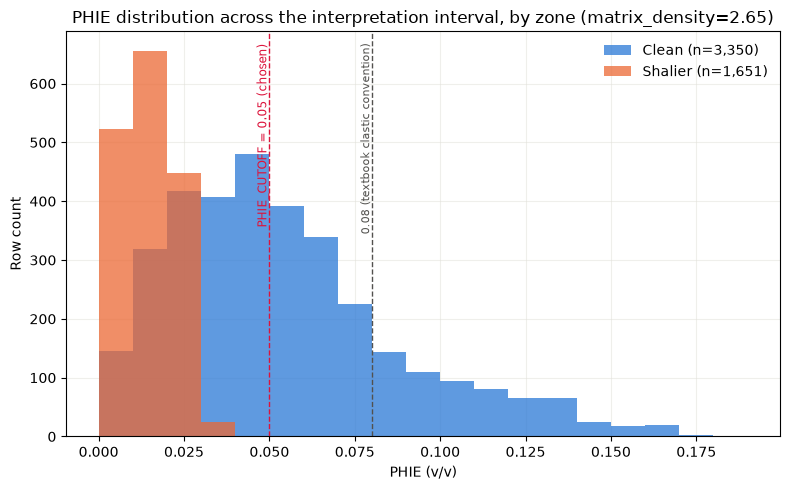

In [31]:
# Cell 33: PHIE histogram by zone, 2.65 working baseline

clean_phie_265 = interpretation_interval_df.loc[clean_mask, "PHIE"]
shalier_phie_265 = interpretation_interval_df.loc[shalier_mask, "PHIE"]

phie_bin_edges = np.arange(0, interpretation_interval_df["PHIE"].max() + 0.02, 0.01)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    clean_phie_265,
    bins=phie_bin_edges,
    color=CLEAN_COLOR,
    alpha=0.75,
    label=f"Clean (n={len(clean_phie_265):,})",
)
ax.hist(
    shalier_phie_265,
    bins=phie_bin_edges,
    color=SHALIER_COLOR,
    alpha=0.75,
    label=f"Shalier (n={len(shalier_phie_265):,})",
)

ax.axvline(0.08, color="#52514e", linestyle="--", linewidth=1)
ax.text(0.08, ax.get_ylim()[1] * 0.97, "0.08 (textbook clastic convention)",
        rotation=90, va="top", ha="right", fontsize=8, color="#52514e")

ax.axvline(0.05, color="crimson", linestyle="--", linewidth=1, zorder=5)
ax.text(0.05, ax.get_ylim()[1] * 0.97, "PHIE_CUTOFF = 0.05 (chosen)",
        rotation=90, va="top", ha="right", fontsize=8.5, color="crimson")

ax.set_xlabel("PHIE (v/v)")
ax.set_ylabel("Row count")
ax.set_title("PHIE distribution across the interpretation interval, by zone (matrix_density=2.65)")
ax.grid(alpha=0.5, color=GRIDLINE_COLOR)
ax.set_axisbelow(True)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "phie_distribution_by_zone.png", dpi=300, bbox_inches="tight")
plt.show()


In [32]:
# Cell 34: Clean-zone PHIE mean/median and % passing candidate porosity cutoffs

clean_phie_mean = clean_phie_265.mean()
clean_phie_median = clean_phie_265.median()

print(f"Clean-zone PHIE mean: {clean_phie_mean:.4f}")
print(f"Clean-zone PHIE median: {clean_phie_median:.4f}")
print()
for cutoff in [0.04, 0.048, 0.05, 0.06, 0.08]:
    pct_pass = (clean_phie_265 >= cutoff).mean() * 100
    print(f"% of Clean-zone rows with PHIE >= {cutoff}: {pct_pass:.1f}%")


Clean-zone PHIE mean: 0.0541
Clean-zone PHIE median: 0.0478

% of Clean-zone rows with PHIE >= 0.04: 61.5%
% of Clean-zone rows with PHIE >= 0.048: 49.7%
% of Clean-zone rows with PHIE >= 0.05: 47.2%
% of Clean-zone rows with PHIE >= 0.06: 35.5%
% of Clean-zone rows with PHIE >= 0.08: 18.6%


### Reading the PHIE cutoff check

Clean-zone PHIE has a mean of 0.0541 and a **median of 0.0478** at the confirmed 2.65
baseline - both well below the low end of the commonly used 0.08-0.10 clastic cutoff range.
Across the candidate cutoffs tested: **61.5% of Clean-zone rows pass at 0.04, 49.7% at 0.048
(the median), 47.2% at 0.05, 35.5% at 0.06, and 18.6% at 0.08** - so even the low end of the
textbook range (0.08) would discard roughly 4 out of 5 Clean-zone rows. This is the same trap
already avoided with VSH: a standard number imported from elsewhere does not automatically fit
this well's own, apparently lower-porosity rock.

**`PHIE_CUTOFF` is set to 0.05** - the median (0.0478) rounded to the same two-decimal
convention used for every other cutoff in this notebook (0.06, 0.08, 0.10), so it sits almost
exactly at the midpoint of this well's own Clean-zone PHIE distribution rather than importing
a textbook value that would not fit it. This replaces the earlier `PHIE_CUTOFF = 0.06`, which
had been anchored the same way but to the Clean-zone median under the since-retracted 2.68
baseline (0.0627, rounded to 0.06) - that anchor stopped applying once the baseline reverted
to 2.65, so the cutoff itself is re-derived here rather than carried forward unchanged. The
flag is created next, in Step 12.

## STEP 12 - Interpretation flags

Three cutoffs, all already decided and documented earlier in this notebook, are applied now:

- **`VSH_CUTOFF = 0.5`** - the standard industry sand/shale convention, corroborated (not
  driven) by this well's own VSH distribution, as shown when the cutoff was first set.
- **`PHIE_CUTOFF = 0.05`** - set to match this well's own Clean-zone median PHIE (0.0478,
  rounded to 0.05) under the confirmed 2.65 baseline, as shown just above. This replaces the
  earlier `PHIE_CUTOFF = 0.06`, which had been anchored the same way but to the Clean-zone
  median under the since-retracted 2.68 baseline (0.0627); that anchor stopped applying once
  the baseline reverted to 2.65, so the cutoff is re-derived here rather than carried forward
  unchanged. The full 0.04/0.048/0.05/0.06/0.08 range is tested again later, in Step 14.
- **`SW_CUTOFF = 0.5`** - the standard hydrocarbon-vs-water convention.

All three flags use the **2.65-matrix-density** PHIE and Sw - the confirmed working columns in
`interpretation_interval_df`.

```text
SAND_FLAG          = VSH <= VSH_CUTOFF
RESERVOIR_FLAG      = SAND_FLAG AND (PHIE >= PHIE_CUTOFF)
POSSIBLE_PAY_FLAG   = RESERVOIR_FLAG AND (SW <= SW_CUTOFF) AND INTERPRETATION_READY_FLAG
                       AND SW_MODEL_VALID
```

**`SW_MODEL_VALID`** (added alongside `SW` in Step 10C) additionally excludes any row where the
assigned model's equation was mathematically undefined at that row: `PHIE = 0` (either model)
or a negative Simandoux inner term. Both cases used to be floored to `SW = 0` or `1` and could
otherwise pass `SW <= SW_CUTOFF` by construction. See Step 10C for why that flooring was wrong.

**Why "possible pay," never "confirmed pay":** these flags describe what GR, RHOB, NPHI and
RT are *consistent with*, using cutoffs and a matrix-density/Rw/Rsh set that were themselves
derived from this well's own logs, not from an independent source. There is no pressure data,
no known fluid contact, no production test, no core-calibrated saturation, and no complete
mud/invasion record for this well. None of that exists to confirm anything here - so nothing
below is called "confirmed." 

In [33]:
# Cell 35: Create SAND_FLAG, RESERVOIR_FLAG, POSSIBLE_PAY_FLAG

VSH_CUTOFF = 0.5
PHIE_CUTOFF = 0.05
SW_CUTOFF = 0.5

interpretation_interval_df["SAND_FLAG"] = interpretation_interval_df["VSH"] <= VSH_CUTOFF

interpretation_interval_df["RESERVOIR_FLAG"] = (
    interpretation_interval_df["SAND_FLAG"]
    & (interpretation_interval_df["PHIE"] >= PHIE_CUTOFF)
)

interpretation_interval_df["POSSIBLE_PAY_FLAG"] = (
    interpretation_interval_df["RESERVOIR_FLAG"]
    & (interpretation_interval_df["SW"] <= SW_CUTOFF)
    & interpretation_interval_df["INTERPRETATION_READY_FLAG"]
    & interpretation_interval_df["SW_MODEL_VALID"]
)

print(f"VSH_CUTOFF={VSH_CUTOFF}, PHIE_CUTOFF={PHIE_CUTOFF}, SW_CUTOFF={SW_CUTOFF}")
print("Flags created: SAND_FLAG, RESERVOIR_FLAG, POSSIBLE_PAY_FLAG (now also requiring SW_MODEL_VALID)")


VSH_CUTOFF=0.5, PHIE_CUTOFF=0.05, SW_CUTOFF=0.5
Flags created: SAND_FLAG, RESERVOIR_FLAG, POSSIBLE_PAY_FLAG (now also requiring SW_MODEL_VALID)


In [34]:
# Cell 36: Row counts and % passing each flag, by zone

for flag in ["SAND_FLAG", "RESERVOIR_FLAG", "POSSIBLE_PAY_FLAG"]:
    zone_counts = interpretation_interval_df.groupby("ZONE_CHARACTER")[flag].agg(
        N_PASSING="sum", N_TOTAL="count"
    )
    zone_counts["PCT_PASSING"] = (zone_counts["N_PASSING"] / zone_counts["N_TOTAL"] * 100).round(1)

    print(f"--- {flag} ---")
    print(zone_counts.to_string())
    n_all = int(interpretation_interval_df[flag].sum())
    pct_all = interpretation_interval_df[flag].mean() * 100
    print(f"Overall: {n_all:,} of {len(interpretation_interval_df):,} rows ({pct_all:.1f}%)")
    print()


--- SAND_FLAG ---
                N_PASSING  N_TOTAL  PCT_PASSING
ZONE_CHARACTER                                 
Clean                3298     3350         98.4
Shalier               318     1651         19.3
Overall: 3,616 of 5,001 rows (72.3%)

--- RESERVOIR_FLAG ---
                N_PASSING  N_TOTAL  PCT_PASSING
ZONE_CHARACTER                                 
Clean                1580     3350         47.2
Shalier                 0     1651          0.0
Overall: 1,580 of 5,001 rows (31.6%)

--- POSSIBLE_PAY_FLAG ---
                N_PASSING  N_TOTAL  PCT_PASSING
ZONE_CHARACTER                                 
Clean                 114     3350          3.4
Shalier                 0     1651          0.0
Overall: 114 of 5,001 rows (2.3%)



### Depth ranges for `POSSIBLE_PAY_FLAG`

Individual passing rows are grouped into broad possible-pay clusters grouped using a 10 m gap
tolerance (adjacent qualifying rows merged; a new cluster starts wherever the gap to the next
qualifying row exceeds 10 m) so the result reads as approximate zones rather than a scattered
row list. This says nothing yet about how continuous or clean each zone is internally - that
is Step 13 (thickness / net-to-gross).

In [35]:
# Cell 37: Cluster POSSIBLE_PAY_FLAG rows into broad possible-pay clusters (10 m gap tolerance)

pay_depths = interpretation_interval_df.loc[
    interpretation_interval_df["POSSIBLE_PAY_FLAG"], "DEPTH"
].reset_index(drop=True)

GAP_TOLERANCE_M = 10.0

pay_clusters = []
cluster_top = pay_depths.iloc[0]
cluster_base = pay_depths.iloc[0]
cluster_rows = 1

for depth in pay_depths.iloc[1:]:
    if depth - cluster_base > GAP_TOLERANCE_M:
        pay_clusters.append((cluster_top, cluster_base, cluster_rows))
        cluster_top = depth
        cluster_rows = 0
    cluster_base = depth
    cluster_rows += 1

pay_clusters.append((cluster_top, cluster_base, cluster_rows))

pay_clusters_df = pd.DataFrame(
    pay_clusters, columns=["DEPTH_TOP", "DEPTH_BASE", "N_ROWS"]
)
pay_clusters_df["SPAN_M"] = (pay_clusters_df["DEPTH_BASE"] - pay_clusters_df["DEPTH_TOP"]).round(2)

print(f"Total POSSIBLE_PAY_FLAG rows: {len(pay_depths):,}")
print(f"Grouped into {len(pay_clusters_df)} broad possible-pay clusters (gap tolerance {GAP_TOLERANCE_M} m):")
print(pay_clusters_df.to_string(index=False))


Total POSSIBLE_PAY_FLAG rows: 114
Grouped into 4 broad possible-pay clusters (gap tolerance 10.0 m):
 DEPTH_TOP  DEPTH_BASE  N_ROWS  SPAN_M
    2772.6      2772.6       1     0.0
    2788.8      2795.7      24     6.9
    2806.8      2821.8      22    15.0
    3050.7      3064.2      67    13.5


### Reading the flag results

`SAND_FLAG` passes for 98.4% of the Clean zone (3,298/3,350) but only 19.3% of the Shalier
zone (318/1,651) - consistent with how the zones were originally defined by GR, and unchanged
by the `PHIE_CUTOFF` re-derivation just above since `SAND_FLAG` depends only on VSH. Adding
the PHIE cutoff drops this sharply: `RESERVOIR_FLAG` now passes for **47.2%** of the Clean
zone (1,580/3,350) and **0%** of the Shalier zone - every Shalier-zone row falls below the
0.05 PHIE cutoff, even the ones with low enough VSH to pass `SAND_FLAG`. Adding the Sw cutoff
narrows this further: `POSSIBLE_PAY_FLAG` now passes for **114 rows**, **all in the Clean zone
(3.4% of it)**, none in the Shalier zone.

The possible-pay rows cluster into a handful of broad possible-pay clusters grouped using a
10 m gap tolerance, shown in the table above - all in the Clean zone, one clearly the largest.
Even within these clusters the passing rows are not perfectly continuous - Step 13 will
quantify how much of each gross interval is actually net pay.

No thickness or net-to-gross has been calculated - that is Step 13.

## STEP 13 - Thickness summary

**Stated explicitly:** thickness below is measured by **counting flagged 0.1 m depth
samples** (each qualifying row represents one 0.1 m sample of log), **not by identifying
genuinely contiguous beds**. Step 12's cluster table already showed the main multi-row
possible-pay clusters are not solid - qualifying rows are interbedded with non-qualifying ones
inside those spans (compare each cluster's `SPAN_M` there against its `N_ROWS` here). So
"gross span" (top-to-base of an interval) and "net thickness" (sum of qualifying 0.1 m
samples) are genuinely different numbers here, and both are reported below - net-to-gross
alone would hide exactly the gappiness Step 12 already found.

In [36]:
# Cell 38: Thickness summary (gross, net sand/reservoir/pay, NTG, average VSH/PHIE/SW), by zone

DEPTH_STEP_M = 0.1

def thickness_row(subset_df, label, gross_m):
    net_sand_m = subset_df["SAND_FLAG"].sum() * DEPTH_STEP_M
    return {
        "SEGMENT": label,
        "GROSS_INTERVAL_M": gross_m,
        "NET_SAND_M": net_sand_m,
        "NET_RESERVOIR_M": subset_df["RESERVOIR_FLAG"].sum() * DEPTH_STEP_M,
        "POSSIBLE_NET_PAY_M": subset_df["POSSIBLE_PAY_FLAG"].sum() * DEPTH_STEP_M,
        "NTG_NET_SAND_OVER_GROSS": net_sand_m / gross_m,
        "VSH_MEAN": subset_df["VSH"].mean(),
        "PHIE_MEAN": subset_df["PHIE"].mean(),
        "SW_MEAN": subset_df["SW"].mean(),
    }

clean_gross_m = ZONE_SPLIT_DEPTH_M - INTERPRETATION_TOP_M
shalier_gross_m = INTERPRETATION_BASE_M - ZONE_SPLIT_DEPTH_M
whole_gross_m = INTERPRETATION_BASE_M - INTERPRETATION_TOP_M

thickness_summary = pd.DataFrame(
    [
        thickness_row(interpretation_interval_df.loc[clean_mask], "Clean", clean_gross_m),
        thickness_row(interpretation_interval_df.loc[shalier_mask], "Shalier", shalier_gross_m),
        thickness_row(interpretation_interval_df, "Whole interval (combined)", whole_gross_m),
    ]
).round(4)

print(thickness_summary.to_string(index=False))


                  SEGMENT  GROSS_INTERVAL_M  NET_SAND_M  NET_RESERVOIR_M  POSSIBLE_NET_PAY_M  NTG_NET_SAND_OVER_GROSS  VSH_MEAN  PHIE_MEAN  SW_MEAN
                    Clean             335.0       329.8            158.0                11.4                   0.9845    0.1178     0.0541   0.8546
                  Shalier             165.0        31.8              0.0                 0.0                   0.1927    0.7022     0.0140   0.9835
Whole interval (combined)             500.0       361.6            158.0                11.4                   0.7232    0.3107     0.0409   0.8907


### Reading the thickness summary

The Shalier zone's contribution is shown plainly rather than folded away: **net reservoir and
possible net pay are both exactly 0.0 m** there, even though it does carry 31.8 m of net
"sand" by the VSH<=0.5 test alone (19.3% of its 165.0 m gross) - none of that sand clears the
PHIE cutoff.

Gross-vs-net, using Step 12's own cluster table: the multi-row clusters' combined span is
itself only a small fraction of the whole gross interval, and the possible net pay below is a
further fraction of even that limited gross span - qualifying and non-qualifying samples are
interbedded throughout (compare `POSSIBLE_NET_PAY_M` below against the cluster spans in
Step 12). Net-to-gross for the Clean zone as a whole (net sand / gross) is 0.985 - almost the
entire Clean zone passes the VSH cutoff - but that number describes shale content only; it
says nothing about porosity or Sw, which is exactly why net reservoir (158.0 m) and possible
net pay (11.4 m) are reported separately rather than derived from NTG alone. Both numbers are
higher than under the previous `PHIE_CUTOFF = 0.06` (118.8 m net reservoir, 8.3 m possible net
pay) - the expected, direct effect of a lower porosity bar passing more rows. The separate
matrix-density question is tested against net pay later in this step, not mixed in here.

## STEP 14 - Three cutoff scenarios

The same flag logic from Step 12 (`SAND_FLAG` -> `RESERVOIR_FLAG` -> `POSSIBLE_PAY_FLAG`, all
requiring `INTERPRETATION_READY_FLAG`) is re-run under three cutoff sets. **Matrix density
stays fixed at 2.65 for all three** - this step tests cutoff judgment only; the separate
matrix-density question (2.65/2.68/2.71) gets its own table against net pay next, not mixed
in here.

| Scenario | VSH cutoff | PHIE cutoff | SW cutoff |
|---|---|---|---|
| Conservative | <= 0.4 | >= 0.08 | <= 0.4 |
| Base (already locked) | <= 0.5 | >= 0.05 | <= 0.5 |
| Optimistic | <= 0.6 | >= 0.03 | <= 0.6 |

The Conservative and Optimistic PHIE cutoffs are scaled proportionally to the new Base value
(0.08 = 0.10 x 0.05/0.06, 0.03 = 0.04 x 0.05/0.06, both rounded to two decimals), preserving
the same relative strictness spread used when Base was 0.06.

In [37]:
# Cell 39: Re-run the Step 13 thickness table under three cutoff scenarios

CUTOFF_SCENARIOS = {
    "Conservative": (0.4, 0.08, 0.4),
    "Base": (0.5, 0.05, 0.5),
    "Optimistic": (0.6, 0.03, 0.6),
}

scenario_rows = []

for scenario_name, (vsh_c, phie_c, sw_c) in CUTOFF_SCENARIOS.items():
    scenario_sand = interpretation_interval_df["VSH"] <= vsh_c
    scenario_reservoir = scenario_sand & (interpretation_interval_df["PHIE"] >= phie_c)
    scenario_pay = (
        scenario_reservoir
        & (interpretation_interval_df["SW"] <= sw_c)
        & interpretation_interval_df["INTERPRETATION_READY_FLAG"]
    )

    for label, mask, gross_m in [
        ("Clean", clean_mask, clean_gross_m),
        ("Shalier", shalier_mask, shalier_gross_m),
        ("Whole interval (combined)", pd.Series(True, index=interpretation_interval_df.index), whole_gross_m),
    ]:
        net_sand_m = scenario_sand[mask].sum() * DEPTH_STEP_M
        scenario_rows.append(
            {
                "SCENARIO": scenario_name,
                "SEGMENT": label,
                "GROSS_INTERVAL_M": gross_m,
                "NET_SAND_M": net_sand_m,
                "NET_RESERVOIR_M": scenario_reservoir[mask].sum() * DEPTH_STEP_M,
                "POSSIBLE_NET_PAY_M": scenario_pay[mask].sum() * DEPTH_STEP_M,
                "NTG_NET_SAND_OVER_GROSS": net_sand_m / gross_m,
                "MATRIX_DENSITY": MATRIX_DENSITY_G_CM3,
                "RW": RW,
                "VSH_CUTOFF": vsh_c,
                "PHIE_CUTOFF": phie_c,
                "SW_CUTOFF": sw_c,
            }
        )

scenario_thickness_table = pd.DataFrame(scenario_rows).round(4)

print(scenario_thickness_table.to_string(index=False))


    SCENARIO                   SEGMENT  GROSS_INTERVAL_M  NET_SAND_M  NET_RESERVOIR_M  POSSIBLE_NET_PAY_M  NTG_NET_SAND_OVER_GROSS  MATRIX_DENSITY     RW  VSH_CUTOFF  PHIE_CUTOFF  SW_CUTOFF
Conservative                     Clean             335.0       324.1             62.3                 1.1                   0.9675            2.65 0.0085         0.4         0.08        0.4
Conservative                   Shalier             165.0        13.5              0.0                 0.0                   0.0818            2.65 0.0085         0.4         0.08        0.4
Conservative Whole interval (combined)             500.0       337.6             62.3                 1.1                   0.6752            2.65 0.0085         0.4         0.08        0.4
        Base                     Clean             335.0       329.8            158.0                11.4                   0.9845            2.65 0.0085         0.5         0.05        0.5
        Base                   Shalier            

In [38]:
# Cell 40: Summary comparison - possible net pay and % of gross, all three scenarios

pay_comparison = (
    scenario_thickness_table.loc[scenario_thickness_table["SEGMENT"] == "Whole interval (combined)"]
    .copy()
)
pay_comparison["PCT_OF_GROSS"] = (
    pay_comparison["POSSIBLE_NET_PAY_M"] / pay_comparison["GROSS_INTERVAL_M"] * 100
).round(2)
pay_comparison = pay_comparison[["SCENARIO", "POSSIBLE_NET_PAY_M", "PCT_OF_GROSS"]].reset_index(drop=True)

print(pay_comparison.to_string(index=False))


    SCENARIO  POSSIBLE_NET_PAY_M  PCT_OF_GROSS
Conservative                 1.1          0.22
        Base                11.4          2.28
  Optimistic                33.7          6.74


### Reading the scenario comparison

Possible net pay swings from **1.1 m (0.22% of gross) under Conservative** to **11.4 m
(2.28%) under Base** to **33.7 m (6.74%) under Optimistic** - roughly a 30x range across three
defensible-sounding cutoff sets, all applied to the exact same logs, same matrix density, same
Rw/Rsh. The Shalier zone contributes exactly **0.0 m of possible net pay** under **all three**
scenarios, including Optimistic - Sw there never clears the Sw cutoff even where PHIE does.
Net reservoir (PHIE cutoff alone, before the Sw test) is a little more nuanced: Shalier stays
at exactly 0.0 m under Conservative and Base, but the loosest Optimistic PHIE cutoff (0.03) is
low enough that 2.5 m of the Shalier zone clears it - none of that additional reservoir carries
through to possible net pay once the Sw cutoff is applied.

**This range reflects reasonable disagreement about where cutoffs should sit, not measurement
uncertainty** - the logs, the QC, and the derived Rw/Rsh are the same in all three columns;
only the judgment calls on VSH/PHIE/SW thresholds differ. The separate matrix-density question
(2.65 quartz / 2.68 mixed / 2.71 calcite) is tested against net pay next, as its own distinct
table - it is not combined with this cutoff range.

## Matrix-density vs. net pay (deferred table)

The Base-case cutoffs (`VSH <= 0.5`, `PHIE >= 0.05`, `SW <= 0.5`) are held fixed throughout -
this table tests the matrix-density assumption in isolation, not combined with the Step 14
cutoff scenarios. For each of the three matrix densities, PHID and PHIE are recalculated, and
so is `Rw` - back-solved fresh from that candidate's own calibration-zone PHIE, exactly as in
the extended sensitivity test in the appendix, rather than reusing the single 2.65-based
value. `Rsh`
(2.244 ohm.m) stays fixed, since it has no PHIE or matrix-density dependency. The fixed
Base-case flags are reapplied, and net reservoir / possible net pay are measured the same way
as Step 13.

In [39]:
# Cell 41: Matrix-density vs net pay, Base-case cutoffs held fixed, Rw recalculated per candidate

matrix_density_pay_rows = []
rw_by_matrix_density_pay = {}

for matrix_density_test in MATRIX_DENSITY_CANDIDATES:
    # --- Rw recalculated fresh for this matrix density (reuses the calibration zone from Step 10A) ---
    calibration_phid_raw_md = (
        (matrix_density_test - calibration_zone["RHOB"]) / (matrix_density_test - FLUID_DENSITY_G_CM3)
    )
    calibration_phid_md = calibration_phid_raw_md.clip(lower=0, upper=0.4)
    calibration_phie_md = calibration_phid_md * (1 - calibration_vsh)
    rw_per_row_md = (calibration_phie_md ** ARCHIE_M * calibration_zone["RT"]) / ARCHIE_A
    rw_md = rw_per_row_md.median()
    rw_by_matrix_density_pay[matrix_density_test] = rw_md

    phid_raw_md = (
        (matrix_density_test - interpretation_interval_df["RHOB"])
        / (matrix_density_test - FLUID_DENSITY_G_CM3)
    )
    phid_md = phid_raw_md.clip(lower=0, upper=0.4)
    phie_md = phid_md * (1 - interpretation_interval_df["VSH"])

    sw_md = pd.Series(np.nan, index=interpretation_interval_df.index)

    # --- Archie, VSH <= SW_MODEL_VSH_LIMIT; PHIE > 0 required, same reasoning as Simandoux ---
    phie_archie_md = phie_md[archie_mask]
    archie_term_md = (
        (ARCHIE_A * rw_md)
        / (phie_archie_md ** ARCHIE_M * interpretation_interval_df.loc[archie_mask, "RT"])
    )
    archie_valid_md = phie_archie_md > 0
    sw_archie_md = pd.Series(np.nan, index=archie_term_md.index)
    sw_archie_md.loc[archie_valid_md] = (archie_term_md[archie_valid_md] ** (1 / SW_N)).clip(0, 1)
    sw_md.loc[archie_mask] = sw_archie_md

    # --- Simandoux, VSH > SW_MODEL_VSH_LIMIT ---
    vsh_shalier_md = interpretation_interval_df.loc[simandoux_mask, "VSH"]
    phie_shalier_md = phie_md[simandoux_mask]
    rt_shalier_md = interpretation_interval_df.loc[simandoux_mask, "RT"]
    sim_term_md = (
        (ARCHIE_A * rw_md) * (1 / rt_shalier_md - vsh_shalier_md / RSH) / (phie_shalier_md ** ARCHIE_M)
    )

    # --- invalid rows (PHIE <= 0, or a negative inner term) get SW = NaN, same fix as Step 10C ---
    sim_valid_md = (phie_shalier_md > 0) & (sim_term_md >= 0)
    sw_shalier_md = pd.Series(np.nan, index=sim_term_md.index)
    sw_shalier_md.loc[sim_valid_md] = (sim_term_md[sim_valid_md] ** (1 / SW_N)).clip(0, 1)
    sw_md.loc[simandoux_mask] = sw_shalier_md

    sand_md = interpretation_interval_df["VSH"] <= VSH_CUTOFF
    reservoir_md = sand_md & (phie_md >= PHIE_CUTOFF)
    pay_md = reservoir_md & (sw_md <= SW_CUTOFF) & interpretation_interval_df["INTERPRETATION_READY_FLAG"]

    for label, mask, gross_m in [
        ("Clean", clean_mask, clean_gross_m),
        ("Shalier", shalier_mask, shalier_gross_m),
        ("Whole interval (combined)", pd.Series(True, index=interpretation_interval_df.index), whole_gross_m),
    ]:
        net_reservoir_m = reservoir_md[mask].sum() * DEPTH_STEP_M
        net_pay_m = pay_md[mask].sum() * DEPTH_STEP_M
        matrix_density_pay_rows.append(
            {
                "MATRIX_DENSITY": matrix_density_test,
                "SEGMENT": label,
                "GROSS_INTERVAL_M": gross_m,
                "NET_RESERVOIR_M": net_reservoir_m,
                "POSSIBLE_NET_PAY_M": net_pay_m,
                "PCT_OF_GROSS": net_pay_m / gross_m * 100,
                "RW": rw_md,
                "VSH_CUTOFF": VSH_CUTOFF,
                "PHIE_CUTOFF": PHIE_CUTOFF,
                "SW_CUTOFF": SW_CUTOFF,
            }
        )

matrix_density_pay_table = pd.DataFrame(matrix_density_pay_rows).round(4)

print("Rw recalculated per matrix-density candidate (same values as the extended sensitivity test in the appendix):")
for md_test, rw_val in rw_by_matrix_density_pay.items():
    print(f"  matrix_density={md_test}: Rw = {rw_val:.4f} ohm.m")
print()
print(matrix_density_pay_table.to_string(index=False))


Rw recalculated per matrix-density candidate (same values as the extended sensitivity test in the appendix):
  matrix_density=2.65: Rw = 0.0085 ohm.m
  matrix_density=2.68: Rw = 0.0095 ohm.m
  matrix_density=2.71: Rw = 0.0104 ohm.m

 MATRIX_DENSITY                   SEGMENT  GROSS_INTERVAL_M  NET_RESERVOIR_M  POSSIBLE_NET_PAY_M  PCT_OF_GROSS     RW  VSH_CUTOFF  PHIE_CUTOFF  SW_CUTOFF
           2.65                     Clean             335.0            158.0                11.4        3.4030 0.0085         0.5         0.05        0.5
           2.65                   Shalier             165.0              0.0                 0.0        0.0000 0.0085         0.5         0.05        0.5
           2.65 Whole interval (combined)             500.0            158.0                11.4        2.2800 0.0085         0.5         0.05        0.5
           2.68                     Clean             335.0            222.3                20.2        6.0299 0.0095         0.5         0.05        0

In [40]:
# Cell 42: Summary - possible net pay vs matrix density, whole interval only

matrix_density_pay_summary = (
    matrix_density_pay_table.loc[matrix_density_pay_table["SEGMENT"] == "Whole interval (combined)"]
    [["MATRIX_DENSITY", "POSSIBLE_NET_PAY_M", "PCT_OF_GROSS"]]
    .reset_index(drop=True)
)

print(matrix_density_pay_summary.to_string(index=False))


 MATRIX_DENSITY  POSSIBLE_NET_PAY_M  PCT_OF_GROSS
           2.65                11.4          2.28
           2.68                20.2          4.04
           2.71                40.9          8.18


### Two sensitivities, side by side

| Source of range | Possible net pay | Held fixed |
|---|---|---|
| **Cutoff choice** (Step 14: Conservative/Base/Optimistic) | **1.1 - 33.7 m** (0.22% - 6.74% of gross) | matrix density (2.65), Rw, Rsh |
| **Matrix density alone** (this table: 2.65/2.68/2.71, Rw recalculated per candidate) | **11.4 - 40.9 m** (2.28% - 8.18% of gross) | VSH/PHIE/SW cutoffs (Base case), Rsh |

Both ranges are wide, and they are **two different kinds of assumption, not one combined
uncertainty**:

- The **cutoff range** is a judgment call - where a reasonable person draws the sand/shale,
  reservoir, and hydrocarbon lines on continuous data that has no natural gap to draw them in
  (shown back in Steps 6 and 11).
- The **matrix-density range** is an unresolved physical question about this rock - what the
  grains are actually made of - that this notebook has evidence on (PEF) but no independent
  confirmation (core, XRD) for.

Neither range should be read as a single "the uncertainty is +/- X m" figure - they answer
different questions, and both are shown so that whichever one gets narrowed first (a cutoff
decision, or a core/PEF-based matrix confirmation) can be seen to matter on its own terms.

Cutoff sensitivity and matrix-density sensitivity were tested independently, each holding
the other fixed. A fully combined worst-case/best-case grid was not built; the true combined
range is likely somewhat wider than either single-axis test shown here.

## STEP 15 - Composite interpreted log panel

A six-track composite, using the same visual conventions as Notebook 1's composite log:
depth increasing downward, curve names and scales at the **top** of each track (not the
bottom), and matching colors where a curve appears in both notebooks (GR green, RHOB red,
NPHI blue, RT purple). `INTERPRETATION_TOP_M` (2,770.0 m) and `INTERPRETATION_BASE_M`
(3,270.0 m) are marked with dashed lines on every track, and the `ZONE_CHARACTER` boundary at
3,105.0 m is both marked (dotted line) and shaded (light background tint over the Shalier
portion) across all six tracks, so the Clean/Shalier split reads at a glance no matter which
track is being looked at.

Notebook 1 deliberately did not shade density-neutron crossover, since QC alone could
not confirm what it meant. This panel identifies it only where the full VSH/porosity/Sw
calculation also supports a possible-pay interpretation, not from log shape alone.

No gold fill or gray hatching is drawn for the crossover itself: the true separation
(0.002-0.003 v/v) is sub-pixel at this track's fixed industry-standard scale, so a filled
region cannot represent it without distorting the axis - the gold locator markers below
indicate where it occurs without overstating its magnitude.

Crossover shape present (RHOB implies more porosity than NPHI): 772 of 5,001 rows
  -> shape + possible pay (gold locator markers below): 96 rows
  -> shape only, not confirmed (no marker): 676 rows
Gold-cluster locator markers placed: 3
  2788.8-2795.7 m
  2806.8-2821.8 m
  3050.7-3064.2 m


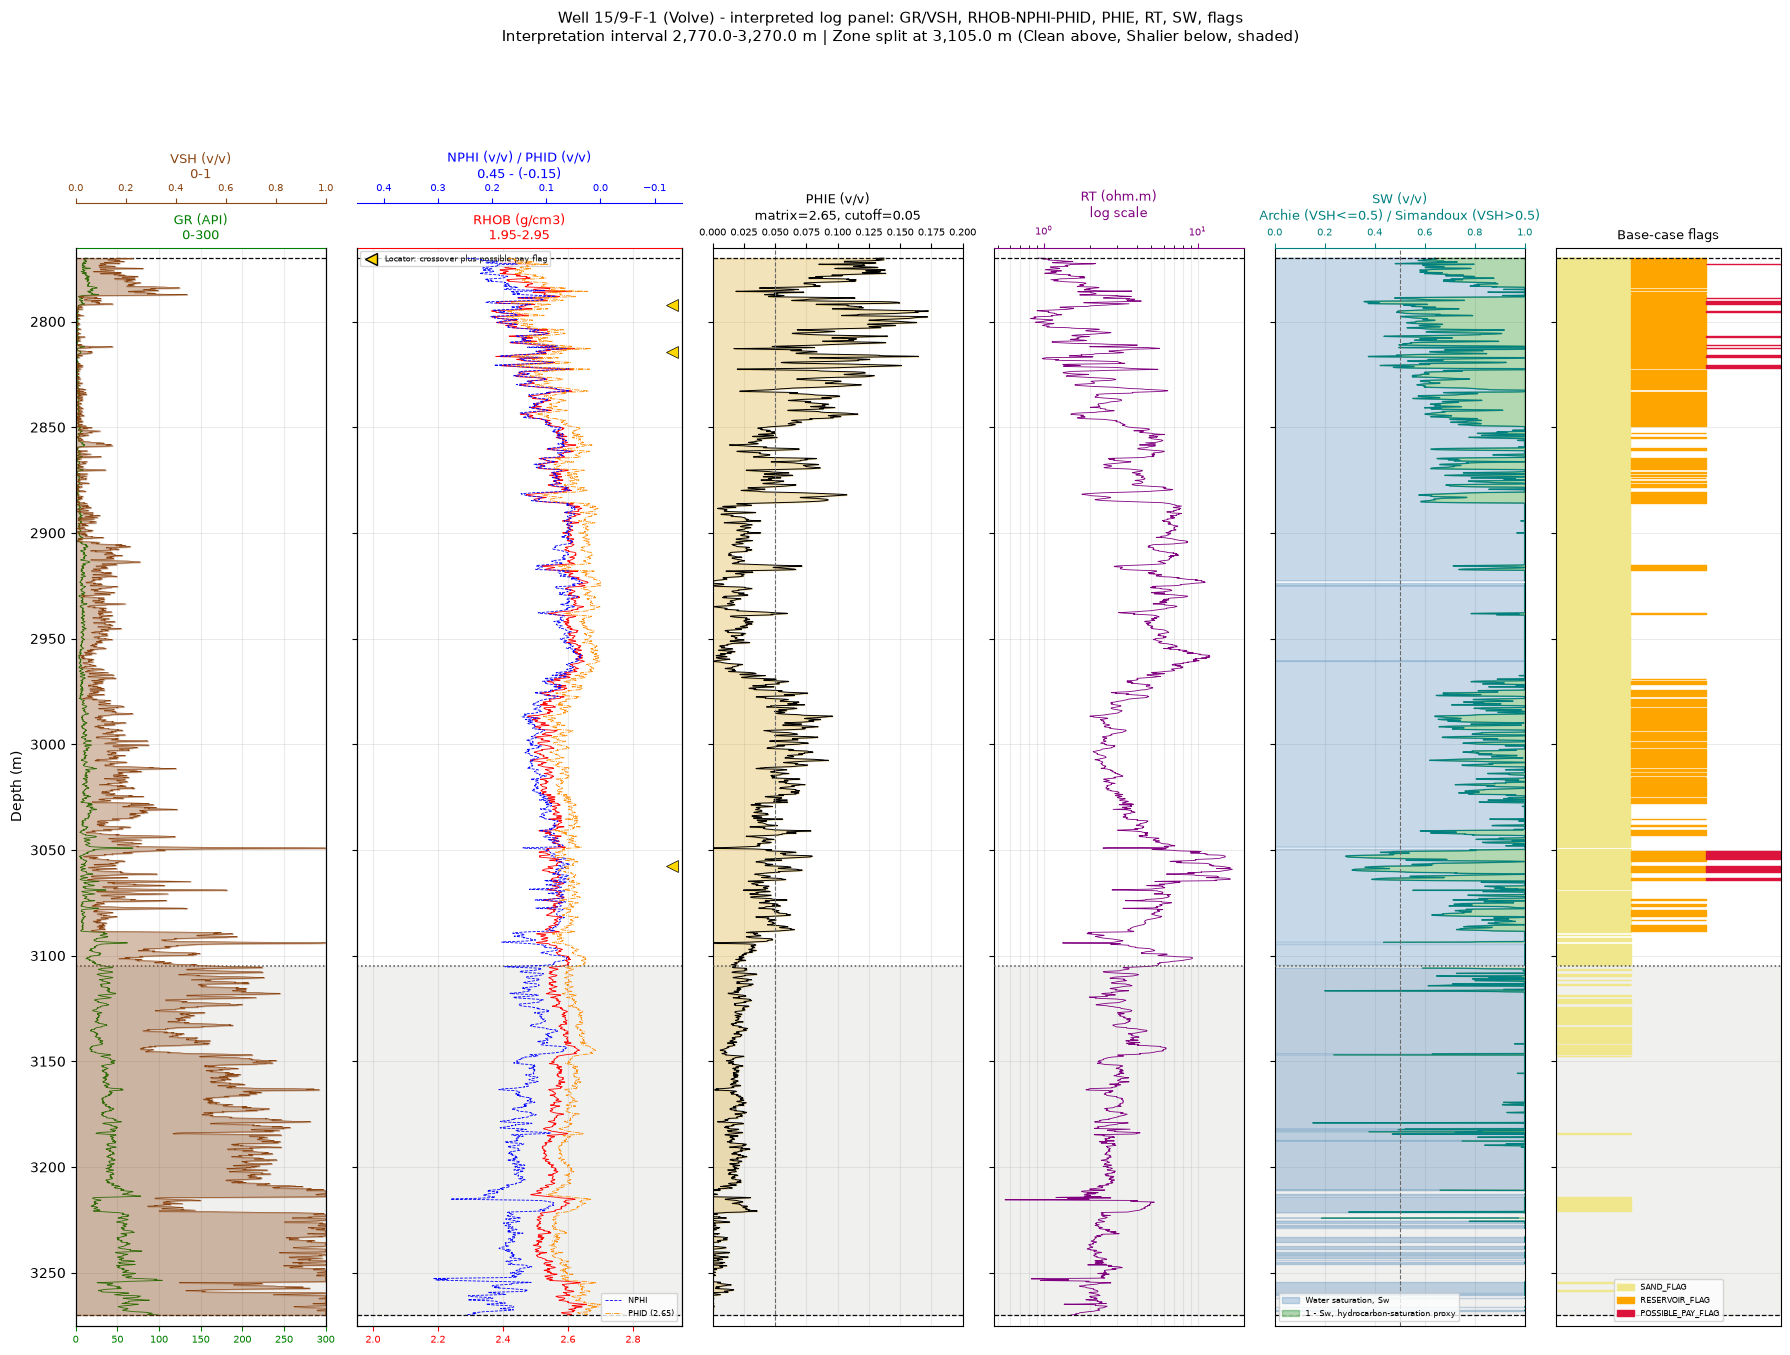

Saved images/interpreted_log_panel.png


In [41]:
# Cell 43: Six-track composite interpreted log panel

import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator

panel_df = interpretation_interval_df.sort_values("DEPTH").reset_index(drop=True)
panel_depth = panel_df["DEPTH"]

def header(ax, label, color):
    ax.xaxis.set_label_position("top")
    ax.xaxis.tick_top()
    ax.set_xlabel(label, color=color, fontsize=9, labelpad=6)
    ax.tick_params(axis="x", colors=color, labelsize=7)
    ax.spines["top"].set_color(color)

def mark_reference_depths(ax):
    ax.axhspan(ZONE_SPLIT_DEPTH_M, INTERPRETATION_BASE_M, color="#898781", alpha=0.12, zorder=0)
    ax.axhline(INTERPRETATION_TOP_M, color="#0b0b0b", linestyle="--", linewidth=0.9, zorder=4)
    ax.axhline(INTERPRETATION_BASE_M, color="#0b0b0b", linestyle="--", linewidth=0.9, zorder=4)
    ax.axhline(ZONE_SPLIT_DEPTH_M, color="#52514e", linestyle=":", linewidth=1.1, zorder=4)
    ax.set_facecolor("white")
    ax.yaxis.set_major_locator(MultipleLocator(50))
    ax.set_axisbelow(True)
    ax.grid(axis="y", which="major", alpha=0.3, linewidth=0.6, zorder=0)

fig = plt.figure(figsize=(22, 14), facecolor="white")
gs = gridspec.GridSpec(1, 6, width_ratios=[1, 1.3, 1, 1, 1, 0.9], wspace=0.12)

ax_gr = fig.add_subplot(gs[0])
ax_rhob = fig.add_subplot(gs[1], sharey=ax_gr)
ax_phie = fig.add_subplot(gs[2], sharey=ax_gr)
ax_rt = fig.add_subplot(gs[3], sharey=ax_gr)
ax_sw = fig.add_subplot(gs[4], sharey=ax_gr)
ax_flags = fig.add_subplot(gs[5], sharey=ax_gr)

PAD_M = 5.0
ax_gr.set_ylim(INTERPRETATION_BASE_M + PAD_M, INTERPRETATION_TOP_M - PAD_M)
ax_gr.set_ylabel("Depth (m)")

# --- Track 1: GR (green) with VSH shaded overlay ---
ax_gr.plot(panel_df["GR"], panel_depth, color="green", linewidth=0.6)
ax_gr.set_xlim(0, 300)
header(ax_gr, "GR (API)\n0-300", "green")
ax_gr.grid(axis="x", alpha=0.25)

ax_vsh = ax_gr.twiny()
ax_vsh.set_facecolor("white")
ax_vsh.fill_betweenx(panel_depth, 0, panel_df["VSH"], color="saddlebrown", alpha=0.35)
ax_vsh.plot(panel_df["VSH"], panel_depth, color="saddlebrown", linewidth=0.4)
ax_vsh.set_xlim(0, 1)
ax_vsh.xaxis.set_label_position("top")
ax_vsh.xaxis.tick_top()
ax_vsh.spines["top"].set_position(("outward", 32))
ax_vsh.spines["top"].set_color("saddlebrown")
ax_vsh.set_xlabel("VSH (v/v)\n0-1", color="saddlebrown", fontsize=9)
ax_vsh.tick_params(axis="x", colors="saddlebrown", labelsize=7)

# --- Track 2: RHOB (red) / NPHI (blue) / PHID (orange) overlaid, + gated crossover shading ---
ax_rhob.plot(panel_df["RHOB"], panel_depth, color="red", linewidth=0.6, zorder=3)
ax_rhob.set_xlim(1.95, 2.95)
header(ax_rhob, "RHOB (g/cm3)\n1.95-2.95", "red")
ax_rhob.tick_params(axis="y", labelleft=False)
ax_rhob.grid(axis="x", alpha=0.25)  # single grid for the whole track - NPHI/PHID twin axis draws no grid of its own

# Crossover shape test, same logic as Notebook 1: RHOB implies more porosity than NPHI
rhob_frac = (panel_df["RHOB"] - 1.95) / (2.95 - 1.95)
nphi_frac = (panel_df["NPHI"] - 0.45) / (-0.15 - 0.45)
both_valid = rhob_frac.notna() & nphi_frac.notna()
crossover_shape = both_valid & (rhob_frac < nphi_frac)
x1 = 1.95 + rhob_frac * (2.95 - 1.95)
x2 = 1.95 + nphi_frac * (2.95 - 1.95)

gold_mask = crossover_shape & panel_df["POSSIBLE_PAY_FLAG"]
hatch_mask = crossover_shape & ~panel_df["POSSIBLE_PAY_FLAG"]

print(f"Crossover shape present (RHOB implies more porosity than NPHI): {int(crossover_shape.sum()):,} of {len(panel_df):,} rows")
print(f"  -> shape + possible pay (gold locator markers below): {int(gold_mask.sum()):,} rows")
print(f"  -> shape only, not confirmed (no marker): {int(hatch_mask.sum()):,} rows")

# No fill/hatching drawn here - see markdown note above. Only the locator markers below
# indicate these depths, using x1/x2 solely to confirm the shape test, not to shade it.

# --- Supplementary locator markers: one per contiguous cluster of gold (crossover plus possible-pay flag) depths ---
# Locator aid only - does not change the gold/hatch shading itself.
gold_depths = panel_depth[gold_mask].reset_index(drop=True)
GOLD_MARKER_GAP_M = 10.0

gold_clusters = []
if len(gold_depths) > 0:
    cluster_top = gold_depths.iloc[0]
    cluster_base = gold_depths.iloc[0]
    for d in gold_depths.iloc[1:]:
        if d - cluster_base > GOLD_MARKER_GAP_M:
            gold_clusters.append((cluster_top, cluster_base))
            cluster_top = d
        cluster_base = d
    gold_clusters.append((cluster_top, cluster_base))

GOLD_MARKER_X = 2.92  # near the right edge of the 1.95-2.95 RHOB track
for cluster_top, cluster_base in gold_clusters:
    cluster_mid = (cluster_top + cluster_base) / 2
    ax_rhob.plot(
        GOLD_MARKER_X, cluster_mid,
        marker="<", color="gold", markeredgecolor="black", markeredgewidth=0.5,
        markersize=9, zorder=10, clip_on=False,
    )

print(f"Gold-cluster locator markers placed: {len(gold_clusters)}")
for cluster_top, cluster_base in gold_clusters:
    print(f"  {cluster_top:.1f}-{cluster_base:.1f} m")

crossover_legend_handles = [
    plt.Line2D([0], [0], marker="<", color="none", markerfacecolor="gold", markeredgecolor="black",
               markersize=8, label="Locator: crossover plus possible-pay flag"),
]
ax_rhob.legend(handles=crossover_legend_handles, fontsize=5.5, loc="upper left")

ax_nphi = ax_rhob.twiny()
ax_nphi.set_facecolor("white")
ax_nphi.plot(panel_df["NPHI"], panel_depth, color="blue", linewidth=0.6, linestyle="--", label="NPHI", zorder=3)
ax_nphi.plot(panel_df["PHID"], panel_depth, color="darkorange", linewidth=0.6, linestyle="-.", label="PHID (2.65)", zorder=3)
ax_nphi.set_xlim(0.45, -0.15)
ax_nphi.xaxis.set_label_position("top")
ax_nphi.xaxis.tick_top()
ax_nphi.spines["top"].set_position(("outward", 32))
ax_nphi.spines["top"].set_color("blue")
ax_nphi.set_xlabel("NPHI (v/v) / PHID (v/v)\n0.45 - (-0.15)", color="blue", fontsize=9)
ax_nphi.tick_params(axis="x", colors="blue", labelsize=7)
ax_nphi.legend(fontsize=6, loc="lower right")

# --- Track 3: PHIE (2.65 working values) ---
ax_phie.plot(panel_df["PHIE"], panel_depth, color="black", linewidth=0.7)
ax_phie.fill_betweenx(panel_depth, 0, panel_df["PHIE"], color="goldenrod", alpha=0.3)
ax_phie.axvline(PHIE_CUTOFF, color="dimgray", linestyle="--", linewidth=0.8)
ax_phie.set_xlim(0, 0.2)
header(ax_phie, "PHIE (v/v)\nmatrix=2.65, cutoff=0.05", "black")
ax_phie.tick_params(axis="y", labelleft=False)
ax_phie.grid(axis="x", alpha=0.25)

# --- Track 4: RT, log scale (purple) ---
positive_rt = panel_df["RT"] > 0
ax_rt.plot(panel_df.loc[positive_rt, "RT"], panel_depth[positive_rt], color="purple", linewidth=0.6)
ax_rt.set_xscale("log")
header(ax_rt, "RT (ohm.m)\nlog scale", "purple")
ax_rt.tick_params(axis="y", labelleft=False)
ax_rt.grid(axis="x", which="both", alpha=0.25)

# --- Track 5: SW (Archie/Simandoux) ---
ax_sw.fill_betweenx(panel_depth, 0, panel_df["SW"], color="steelblue", alpha=0.3, label="Water saturation, Sw")
ax_sw.fill_betweenx(panel_depth, panel_df["SW"], 1, color="green", alpha=0.3, label="1 - Sw, hydrocarbon-saturation proxy")
ax_sw.plot(panel_df["SW"], panel_depth, color="teal", linewidth=0.7)
ax_sw.axvline(SW_CUTOFF, color="dimgray", linestyle="--", linewidth=0.8)
ax_sw.set_xlim(0, 1)
header(ax_sw, "SW (v/v)\nArchie (VSH<=0.5) / Simandoux (VSH>0.5)", "teal")
ax_sw.tick_params(axis="y", labelleft=False)
ax_sw.legend(fontsize=6, loc="lower left")
ax_sw.grid(axis="x", alpha=0.25)

# --- Track 6: SAND_FLAG / RESERVOIR_FLAG / POSSIBLE_PAY_FLAG (Base-case cutoffs) ---
ax_flags.fill_betweenx(panel_depth, 0, 1, where=panel_df["SAND_FLAG"], color="khaki", step="mid")
ax_flags.fill_betweenx(panel_depth, 1, 2, where=panel_df["RESERVOIR_FLAG"], color="orange", step="mid")
ax_flags.fill_betweenx(panel_depth, 2, 3, where=panel_df["POSSIBLE_PAY_FLAG"], color="crimson", step="mid")
ax_flags.set_xlim(0, 3)
ax_flags.set_xticks([])
header(ax_flags, "Base-case flags", "black")
ax_flags.tick_params(axis="y", labelleft=False)
ax_flags.grid(axis="x", alpha=0.25)  # no-op: track is categorical, no x-ticks are set

flag_legend_handles = [
    mpatches.Patch(color="khaki", label="SAND_FLAG"),
    mpatches.Patch(color="orange", label="RESERVOIR_FLAG"),
    mpatches.Patch(color="crimson", label="POSSIBLE_PAY_FLAG"),
]
ax_flags.legend(handles=flag_legend_handles, fontsize=6, loc="lower center")

for ax in [ax_gr, ax_rhob, ax_phie, ax_rt, ax_sw, ax_flags]:
    mark_reference_depths(ax)

fig.suptitle(
    "Well 15/9-F-1 (Volve) - interpreted log panel: GR/VSH, RHOB-NPHI-PHID, PHIE, RT, SW, flags\n"
    "Interpretation interval 2,770.0-3,270.0 m | Zone split at 3,105.0 m (Clean above, Shalier below, shaded)",
    y=1.05,
    fontsize=11,
)

plt.savefig(IMAGES_DIR / "interpreted_log_panel.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved images/interpreted_log_panel.png")


## Supplementary lithology crossplots

Two supplementary crossplots (RHOB-PEF, and the classic density-neutron layout) independently
corroborate the lithology conclusion already used above: this well's Clean zone sits well off
the pure-quartz reference line and closest to the Limestone line, consistent with either a
calcite-cemented, glauconitic sandstone (matching Sodir's own description of the Hugin
Formation, Volve's regional reservoir) or a true limestone/dolomite matrix - the two are not
distinguishable from log data alone, and this well has no confirmed formation tops. What all
three checks (the PEF evidence in Step 9, and the two crossplots) consistently rule out is a
clean, uncemented quartz sandstone; they do not rule out sandstone as a rock type. Full
derivations, verified reference points, and residual statistics are in **Appendix:
development corrections**.

## Final interpretation

- A log-defined interpretation interval of 2,770-3,270 m was evaluated. It should not be
  treated as a confirmed formation interval, since formal formation tops were not integrated.
- Under the base screening assumptions, this workflow identifies **11.4 m** of possible pay.
- The possible-pay estimate is highly sensitive to matrix density, Rw, and the selected VSH,
  PHIE, and Sw cutoffs.
- The result is reported as possible pay, not confirmed net pay.
- Pressure data, fluid contacts, core calibration, and production-test evidence were not
  integrated into this project.

## STEP 16 - Export results

Four CSVs are written to `results/`, closing out this notebook:

1. **`formation_evaluation_results.csv`** - the full interpretation-interval dataframe
   (2,770.0-3,270.0 m, 5,001 rows), carrying the **2.65 matrix-density working values**
   throughout: `DEPTH, GR, CALI, BS, DRHO, RHOB, NPHI, RT, DENSITY_RELIABILITY,
   INTERPRETATION_READY_FLAG, ZONE_CHARACTER, IGR, VSH, PHID_RAW, PHID, PHIE, SW_MODEL, SW,
   SW_MODEL_VALID, SAND_FLAG, RESERVOIR_FLAG, POSSIBLE_PAY_FLAG`. `CALI, BS, DRHO,
   DENSITY_RELIABILITY, INTERPRETATION_READY_FLAG` are QC columns carried straight through
   from Step 1's load of Notebook 1's output - no separate join was needed, since
   `interpretation_interval_df` is a depth-filtered subset of that same loaded dataframe and
   already carries them. `IGR` and `PHID_RAW` are the pre-clip versions of `VSH` and `PHID`
   (see Steps 5 and 7). `SW_MODEL` records which equation was actually applied at each row
   (`Archie` where `VSH <= 0.5`, `Simandoux` otherwise - see Step 10C; this is no longer the
   same split as `ZONE_CHARACTER`). `SW_MODEL_VALID` is included so anyone reading raw `SW`
   values can see which ones are real: `False` marks rows where the assigned model's inner
   term was undefined (`PHIE = 0` under either model, or a negative Simandoux term), where
   `SW` is `NaN` rather than a floored 0 or 1 (see Step 10C).
2. **`interval_summary.csv`** - the Step 13 thickness table (gross, net sand, net reservoir,
   possible net pay, NTG, average VSH/PHIE/SW), split by `ZONE_CHARACTER` and combined. This
   grouping is unchanged - `ZONE_CHARACTER` still describes geology by depth, independent of
   which Sw equation applied to any given row within it.
3. **`uncertainty_scenarios.csv`** - the Step 14 cutoff scenarios (Conservative/Base/
   Optimistic) and the matrix-density table (2.65/2.68/2.71) combined into one file, each row
   labelled with which type of uncertainty it represents, plus a final note row carrying the
   combined-grid limitation already stated after Step 14. The actual assumption values behind
   each row are now explicit columns - `MATRIX_DENSITY, RW, VSH_CUTOFF, PHIE_CUTOFF,
   SW_CUTOFF` - not only text embedded in `LABEL`/`UNCERTAINTY_TYPE`.
4. **`possible_pay_zones.csv`** - **new**: the `POSSIBLE_PAY_FLAG` rows grouped into broad
   possible-pay clusters using a 10 m gap tolerance (same grouping as Step 12), one row per cluster,
   with `ZONE_CHARACTER`, `SW_MODEL`, and the mean/min/max of `VSH`, `PHIE`, `SW`, and `RT`
   within it. This is the table for anyone who only wants the pay zones themselves, not the
   full 5,001-row export.

No new calculations are introduced here - this step only writes out results already computed
in the notebook.

In [42]:
# Cell 46: Export formation_evaluation_results.csv

formation_evaluation_results = interpretation_interval_df[
    [
        "DEPTH", "GR", "CALI", "BS", "DRHO", "RHOB", "NPHI", "RT", "DENSITY_RELIABILITY",
        "INTERPRETATION_READY_FLAG", "ZONE_CHARACTER", "IGR", "VSH", "PHID_RAW", "PHID", "PHIE",
        "SW_MODEL", "SW", "SW_MODEL_VALID", "SAND_FLAG", "RESERVOIR_FLAG", "POSSIBLE_PAY_FLAG",
    ]
].copy()

formation_evaluation_results.to_csv(RESULTS_DIR / "formation_evaluation_results.csv", index=False)

print(f"formation_evaluation_results.csv: {formation_evaluation_results.shape[0]:,} rows, "
      f"{formation_evaluation_results.shape[1]} columns")
print(f"Columns: {list(formation_evaluation_results.columns)}")


formation_evaluation_results.csv: 5,001 rows, 22 columns
Columns: ['DEPTH', 'GR', 'CALI', 'BS', 'DRHO', 'RHOB', 'NPHI', 'RT', 'DENSITY_RELIABILITY', 'INTERPRETATION_READY_FLAG', 'ZONE_CHARACTER', 'IGR', 'VSH', 'PHID_RAW', 'PHID', 'PHIE', 'SW_MODEL', 'SW', 'SW_MODEL_VALID', 'SAND_FLAG', 'RESERVOIR_FLAG', 'POSSIBLE_PAY_FLAG']


In [43]:
# Cell 47: Export interval_summary.csv (Step 13 thickness table)

thickness_summary.to_csv(RESULTS_DIR / "interval_summary.csv", index=False)

print(f"interval_summary.csv: {thickness_summary.shape[0]:,} rows, {thickness_summary.shape[1]} columns")
print(f"Columns: {list(thickness_summary.columns)}")


interval_summary.csv: 3 rows, 9 columns
Columns: ['SEGMENT', 'GROSS_INTERVAL_M', 'NET_SAND_M', 'NET_RESERVOIR_M', 'POSSIBLE_NET_PAY_M', 'NTG_NET_SAND_OVER_GROSS', 'VSH_MEAN', 'PHIE_MEAN', 'SW_MEAN']


In [44]:
# Cell 48: Export uncertainty_scenarios.csv (Step 14 cutoff scenarios + matrix-density table, combined)

scenario_export = scenario_thickness_table.copy()
scenario_export["UNCERTAINTY_TYPE"] = "Cutoff scenario (VSH/PHIE/SW), matrix density fixed at 2.65"
scenario_export["LABEL"] = scenario_export["SCENARIO"]
scenario_export["PCT_OF_GROSS_POSSIBLE_PAY"] = (
    scenario_export["POSSIBLE_NET_PAY_M"] / scenario_export["GROSS_INTERVAL_M"] * 100
)

matrix_export = matrix_density_pay_table.copy()
matrix_export["UNCERTAINTY_TYPE"] = "Matrix density, Base-case cutoffs fixed (VSH<=0.5, PHIE>=0.05, SW<=0.5)"
matrix_export["LABEL"] = matrix_export["MATRIX_DENSITY"].astype(str)
matrix_export = matrix_export.merge(
    thickness_summary[["SEGMENT", "NET_SAND_M", "NTG_NET_SAND_OVER_GROSS"]],
    on="SEGMENT", how="left",
)
matrix_export["PCT_OF_GROSS_POSSIBLE_PAY"] = (
    matrix_export["POSSIBLE_NET_PAY_M"] / matrix_export["GROSS_INTERVAL_M"] * 100
)

EXPORT_COLUMNS = [
    "UNCERTAINTY_TYPE", "LABEL", "SEGMENT", "GROSS_INTERVAL_M", "NET_SAND_M",
    "NET_RESERVOIR_M", "POSSIBLE_NET_PAY_M", "NTG_NET_SAND_OVER_GROSS",
    "PCT_OF_GROSS_POSSIBLE_PAY", "MATRIX_DENSITY", "RW", "VSH_CUTOFF", "PHIE_CUTOFF", "SW_CUTOFF",
]

uncertainty_scenarios = pd.concat(
    [scenario_export[EXPORT_COLUMNS], matrix_export[EXPORT_COLUMNS]],
    ignore_index=True,
)
uncertainty_scenarios["NOTE"] = ""

note_row = pd.DataFrame([{
    "UNCERTAINTY_TYPE": "Note",
    "LABEL": "",
    "SEGMENT": "",
    "GROSS_INTERVAL_M": np.nan,
    "NET_SAND_M": np.nan,
    "NET_RESERVOIR_M": np.nan,
    "POSSIBLE_NET_PAY_M": np.nan,
    "NTG_NET_SAND_OVER_GROSS": np.nan,
    "PCT_OF_GROSS_POSSIBLE_PAY": np.nan,
    "MATRIX_DENSITY": np.nan,
    "RW": np.nan,
    "VSH_CUTOFF": np.nan,
    "PHIE_CUTOFF": np.nan,
    "SW_CUTOFF": np.nan,
    "NOTE": (
        "Cutoff sensitivity and matrix-density sensitivity were tested independently, each "
        "holding the other fixed. A fully combined worst-case/best-case grid was not built; "
        "the true combined range is likely somewhat wider than either single-axis test shown here."
    ),
}])

uncertainty_scenarios = pd.concat([uncertainty_scenarios, note_row], ignore_index=True)
uncertainty_scenarios.to_csv(RESULTS_DIR / "uncertainty_scenarios.csv", index=False)

print(f"uncertainty_scenarios.csv: {uncertainty_scenarios.shape[0]:,} rows, {uncertainty_scenarios.shape[1]} columns")
print(f"Columns: {list(uncertainty_scenarios.columns)}")
print()
print(uncertainty_scenarios.to_string(index=False))


uncertainty_scenarios.csv: 19 rows, 15 columns
Columns: ['UNCERTAINTY_TYPE', 'LABEL', 'SEGMENT', 'GROSS_INTERVAL_M', 'NET_SAND_M', 'NET_RESERVOIR_M', 'POSSIBLE_NET_PAY_M', 'NTG_NET_SAND_OVER_GROSS', 'PCT_OF_GROSS_POSSIBLE_PAY', 'MATRIX_DENSITY', 'RW', 'VSH_CUTOFF', 'PHIE_CUTOFF', 'SW_CUTOFF', 'NOTE']

                                                       UNCERTAINTY_TYPE        LABEL                   SEGMENT  GROSS_INTERVAL_M  NET_SAND_M  NET_RESERVOIR_M  POSSIBLE_NET_PAY_M  NTG_NET_SAND_OVER_GROSS  PCT_OF_GROSS_POSSIBLE_PAY  MATRIX_DENSITY     RW  VSH_CUTOFF  PHIE_CUTOFF  SW_CUTOFF                                                                                                                                                                                                                                                           NOTE
            Cutoff scenario (VSH/PHIE/SW), matrix density fixed at 2.65 Conservative                     Clean             335.0       324.1             

In [45]:
# Cell 49: Cluster POSSIBLE_PAY_FLAG rows for the possible_pay_zones.csv export

pay_rows = interpretation_interval_df.loc[interpretation_interval_df["POSSIBLE_PAY_FLAG"]].copy()
pay_rows = pay_rows.sort_values("DEPTH").reset_index(drop=True)

PAY_ZONE_GAP_TOLERANCE_M = 10.0

cluster_ids = [0] * len(pay_rows)
if len(pay_rows):
    current_cluster = 0
    cluster_base_depth = pay_rows.loc[0, "DEPTH"]
    for i in range(1, len(pay_rows)):
        depth = pay_rows.loc[i, "DEPTH"]
        if depth - cluster_base_depth > PAY_ZONE_GAP_TOLERANCE_M:
            current_cluster += 1
        cluster_base_depth = depth
        cluster_ids[i] = current_cluster
pay_rows["CLUSTER_ID"] = cluster_ids

def summarise_pay_cluster(cluster_df):
    depth_top = cluster_df["DEPTH"].min()
    depth_base = cluster_df["DEPTH"].max()
    zones = cluster_df["ZONE_CHARACTER"].unique()
    models = cluster_df["SW_MODEL"].unique()
    return pd.Series({
        "DEPTH_TOP_M": depth_top,
        "DEPTH_BASE_M": depth_base,
        "THICKNESS_M": depth_base - depth_top + DEPTH_STEP_M,
        "N_ROWS": len(cluster_df),
        "ZONE_CHARACTER": zones[0] if len(zones) == 1 else "Mixed",
        "SW_MODEL": models[0] if len(models) == 1 else "Mixed",
        "VSH_MEAN": cluster_df["VSH"].mean(),
        "VSH_MIN": cluster_df["VSH"].min(),
        "VSH_MAX": cluster_df["VSH"].max(),
        "PHIE_MEAN": cluster_df["PHIE"].mean(),
        "PHIE_MIN": cluster_df["PHIE"].min(),
        "PHIE_MAX": cluster_df["PHIE"].max(),
        "SW_MEAN": cluster_df["SW"].mean(),
        "SW_MIN": cluster_df["SW"].min(),
        "SW_MAX": cluster_df["SW"].max(),
        "RT_MEAN": cluster_df["RT"].mean(),
        "RT_MIN": cluster_df["RT"].min(),
        "RT_MAX": cluster_df["RT"].max(),
    })

pay_zone_columns = [
    "DEPTH_TOP_M", "DEPTH_BASE_M", "THICKNESS_M", "N_ROWS", "ZONE_CHARACTER", "SW_MODEL",
    "VSH_MEAN", "VSH_MIN", "VSH_MAX", "PHIE_MEAN", "PHIE_MIN", "PHIE_MAX",
    "SW_MEAN", "SW_MIN", "SW_MAX", "RT_MEAN", "RT_MIN", "RT_MAX",
]

if len(pay_rows):
    possible_pay_zones = (
        pay_rows.groupby("CLUSTER_ID", group_keys=False)
        .apply(summarise_pay_cluster, include_groups=False)
        .reset_index(drop=True)
    )
    possible_pay_zones[[c for c in pay_zone_columns if c not in ("ZONE_CHARACTER", "SW_MODEL")]] = (
        possible_pay_zones[[c for c in pay_zone_columns if c not in ("ZONE_CHARACTER", "SW_MODEL")]].round(4)
    )
else:
    possible_pay_zones = pd.DataFrame(columns=pay_zone_columns)

print(f"POSSIBLE_PAY_FLAG rows: {len(pay_rows):,}, grouped into {len(possible_pay_zones)} broad "
      f"possible-pay clusters (gap tolerance {PAY_ZONE_GAP_TOLERANCE_M} m):")
print(possible_pay_zones.to_string(index=False))


POSSIBLE_PAY_FLAG rows: 114, grouped into 4 broad possible-pay clusters (gap tolerance 10.0 m):
 DEPTH_TOP_M  DEPTH_BASE_M  THICKNESS_M  N_ROWS ZONE_CHARACTER SW_MODEL  VSH_MEAN  VSH_MIN  VSH_MAX  PHIE_MEAN  PHIE_MIN  PHIE_MAX  SW_MEAN  SW_MIN  SW_MAX  RT_MEAN  RT_MIN  RT_MAX
      2772.6        2772.6          0.1       1          Clean   Archie    0.1182   0.1182   0.1182     0.1200    0.1200    0.1200   0.4823  0.4823  0.4823   2.1673  2.1673  2.1673
      2788.8        2795.7          7.0      24          Clean   Archie    0.0592   0.0000   0.1244     0.1423    0.0887    0.1727   0.4342  0.3577  0.4980   2.1929  0.9305  4.2973
      2806.8        2821.8         15.1      22          Clean   Archie    0.0095   0.0000   0.0547     0.1319    0.0816    0.1647   0.4594  0.3747  0.4986   2.1896  1.3574  4.6931
      3050.7        3064.2         13.6      67          Clean   Archie    0.1055   0.0309   0.2620     0.0625    0.0506    0.0797   0.3922  0.2840  0.4966  14.0948  8.9840 16.7668

In [46]:
# Cell 50: Export possible_pay_zones.csv

possible_pay_zones.to_csv(RESULTS_DIR / "possible_pay_zones.csv", index=False)

print(f"possible_pay_zones.csv: {possible_pay_zones.shape[0]:,} rows, {possible_pay_zones.shape[1]} columns")
print(f"Columns: {list(possible_pay_zones.columns)}")


possible_pay_zones.csv: 4 rows, 18 columns
Columns: ['DEPTH_TOP_M', 'DEPTH_BASE_M', 'THICKNESS_M', 'N_ROWS', 'ZONE_CHARACTER', 'SW_MODEL', 'VSH_MEAN', 'VSH_MIN', 'VSH_MAX', 'PHIE_MEAN', 'PHIE_MIN', 'PHIE_MAX', 'SW_MEAN', 'SW_MIN', 'SW_MAX', 'RT_MEAN', 'RT_MIN', 'RT_MAX']


In [47]:
# Cell 51: Confirm all four files exist in results/, with row/column counts read back from disk

export_files = [
    "formation_evaluation_results.csv",
    "interval_summary.csv",
    "uncertainty_scenarios.csv",
    "possible_pay_zones.csv",
]

print("Final export check - files re-read from disk:")
for fname in export_files:
    fpath = RESULTS_DIR / fname
    exists = fpath.exists()
    if exists:
        check_df = pd.read_csv(fpath)
        print(f"  {fname}: EXISTS, {check_df.shape[0]:,} rows, {check_df.shape[1]} columns")
    else:
        print(f"  {fname}: MISSING")


Final export check - files re-read from disk:
  formation_evaluation_results.csv: EXISTS, 5,001 rows, 22 columns
  interval_summary.csv: EXISTS, 3 rows, 9 columns
  uncertainty_scenarios.csv: EXISTS, 19 rows, 15 columns
  possible_pay_zones.csv: EXISTS, 4 rows, 18 columns


## Appendix: development corrections

This notebook was built iteratively, and several assumptions made early on turned out, on
closer inspection, to be wrong. Rather than quietly editing them away, each correction is kept
here in full - what was originally assumed, why it did not hold up, and what replaced it - so
the reasoning stays auditable. The main flow above states only the current, corrected
conclusions; this appendix is where the "why" lives. It also carries the detailed crossplot
derivations and sensitivity diagnostics that support, but are not required to follow, the main
analytical flow.

### A1. Matrix-density sensitivity, extended through Sw

Now that `Sw` exists, the same three matrix densities (2.65 quartz / 2.68 mixed / 2.71
calcite) are carried all the way through PHID, PHIE, **and now Rw itself**, to `Sw`.

**A previous version of this test held `Rw` fixed at 0.0085 ohm.m - the single value derived
once in Step 10A under the 2.65 working baseline - reasoning that Rw is a resistivity
property, not a matrix-density one. That reasoning was wrong, and is corrected here:** `Rw` is
back-solved from `PHIE` in the calibration zone (Step 10A: `Rw = PHIE^m x Rt / a`, assuming
Sw=1), and `PHIE` is itself matrix-density-dependent. A different matrix density therefore
produces a different calibration-zone PHIE, and so a different Rw - reusing one Rw value
across all three matrix densities silently mixed a 2.65-based Rw into the 2.68 and 2.71 Sw
calculations, which was not internally consistent. **Rw is recalculated fresh below for each
candidate**, from that candidate's own calibration-zone PHIE, exactly as Step 10A did for
2.65. `Rsh` (2.244 ohm.m) is unaffected and stays fixed - it comes directly from RT in the
high-VSH rows, with no PHIE or matrix-density dependency in its derivation. No flags are
created in this step.

In [48]:
# Cell 52: Matrix-density sensitivity, extended through Sw - Rw recalculated per candidate

sw_sensitivity_rows = []
rw_by_matrix_density = {}

for matrix_density_test in MATRIX_DENSITY_CANDIDATES:
    # --- Rw recalculated fresh for this matrix density, exactly as Step 10A did for 2.65 ---
    calibration_phid_raw_test = (
        (matrix_density_test - calibration_zone["RHOB"]) / (matrix_density_test - FLUID_DENSITY_G_CM3)
    )
    calibration_phid_test = calibration_phid_raw_test.clip(lower=0, upper=0.4)
    calibration_phie_test = calibration_phid_test * (1 - calibration_vsh)
    rw_per_row_test = (calibration_phie_test ** ARCHIE_M * calibration_zone["RT"]) / ARCHIE_A
    rw_test = rw_per_row_test.median()
    rw_by_matrix_density[matrix_density_test] = rw_test

    phid_raw_test = (
        (matrix_density_test - interpretation_interval_df["RHOB"])
        / (matrix_density_test - FLUID_DENSITY_G_CM3)
    )
    phid_test = phid_raw_test.clip(lower=0, upper=0.4)
    phie_test = phid_test * (1 - interpretation_interval_df["VSH"])

    sw_test = pd.Series(np.nan, index=interpretation_interval_df.index)

    # --- Archie, VSH <= SW_MODEL_VSH_LIMIT; PHIE > 0 required, same reasoning as Simandoux ---
    phie_archie_test = phie_test[archie_mask]
    archie_term_test = (
        (ARCHIE_A * rw_test)
        / (
            phie_archie_test ** ARCHIE_M
            * interpretation_interval_df.loc[archie_mask, "RT"]
        )
    )
    archie_valid_test = phie_archie_test > 0
    sw_archie_test = pd.Series(np.nan, index=archie_term_test.index)
    sw_archie_test.loc[archie_valid_test] = (archie_term_test[archie_valid_test] ** (1 / SW_N)).clip(0, 1)
    sw_test.loc[archie_mask] = sw_archie_test

    # --- Simandoux, VSH > SW_MODEL_VSH_LIMIT ---
    vsh_shalier_test = interpretation_interval_df.loc[simandoux_mask, "VSH"]
    phie_shalier_test = phie_test[simandoux_mask]
    rt_shalier_test = interpretation_interval_df.loc[simandoux_mask, "RT"]
    sim_term_test = (
        (ARCHIE_A * rw_test) * (1 / rt_shalier_test - vsh_shalier_test / RSH) / (phie_shalier_test ** ARCHIE_M)
    )

    # --- invalid rows (PHIE <= 0, or a negative inner term) get SW = NaN, same fix as Step 10C ---
    sim_valid_test = (phie_shalier_test > 0) & (sim_term_test >= 0)
    sw_shalier_test = pd.Series(np.nan, index=sim_term_test.index)
    sw_shalier_test.loc[sim_valid_test] = (sim_term_test[sim_valid_test] ** (1 / SW_N)).clip(0, 1)
    sw_test.loc[simandoux_mask] = sw_shalier_test

    zone_summary = (
        pd.DataFrame({"SW": sw_test, "ZONE_CHARACTER": interpretation_interval_df["ZONE_CHARACTER"]})
        .groupby("ZONE_CHARACTER")["SW"]
        .agg(["count", "mean", "median"])
        .round(3)
    )
    zone_summary.insert(0, "RW_OHM_M", round(rw_test, 4))
    zone_summary.insert(0, "MATRIX_DENSITY", matrix_density_test)
    sw_sensitivity_rows.append(zone_summary)

    if matrix_density_test == 2.65:
        sw_at_265 = sw_test.copy()
    elif matrix_density_test == 2.68:
        sw_at_268 = sw_test.copy()
    elif matrix_density_test == 2.71:
        sw_at_271 = sw_test.copy()

sw_matrix_density_sensitivity = pd.concat(sw_sensitivity_rows).reset_index()

print("Rw recalculated per matrix-density candidate:")
for md_test, rw_val in rw_by_matrix_density.items():
    print(f"  matrix_density={md_test}: Rw = {rw_val:.4f} ohm.m")
print()
print(sw_matrix_density_sensitivity.to_string(index=False))


Rw recalculated per matrix-density candidate:
  matrix_density=2.65: Rw = 0.0085 ohm.m
  matrix_density=2.68: Rw = 0.0095 ohm.m
  matrix_density=2.71: Rw = 0.0104 ohm.m

ZONE_CHARACTER  MATRIX_DENSITY  RW_OHM_M  count  mean  median
         Clean            2.65    0.0085   3319 0.855   0.940
       Shalier            2.65    0.0085   1289 0.984   1.000
         Clean            2.68    0.0095   3334 0.765   0.750
       Shalier            2.68    0.0095   1289 0.951   1.000
         Clean            2.71    0.0104   3334 0.659   0.634
       Shalier            2.71    0.0104   1289 0.898   1.000


In [49]:
# Cell 53: Percentage of the Clean zone with Sw <= 0.5, by matrix density

for matrix_density_test, sw_test in [(2.65, sw_at_265), (2.68, sw_at_268), (2.71, sw_at_271)]:
    pct_clean_le_05 = (sw_test[clean_mask] <= 0.5).mean() * 100
    print(f"matrix_density={matrix_density_test}: {pct_clean_le_05:.1f}% of Clean-zone rows have Sw <= 0.5")


matrix_density=2.65: 3.5% of Clean-zone rows have Sw <= 0.5
matrix_density=2.68: 6.1% of Clean-zone rows have Sw <= 0.5
matrix_density=2.71: 12.3% of Clean-zone rows have Sw <= 0.5


**Reading the extended sensitivity test:** `Rw` rises with matrix density, since a denser
assumed matrix implies more calibration-zone PHIE for the same RHOB, which back-solves to a
higher Rw: **0.0085 ohm.m at 2.65, 0.0095 ohm.m at 2.68, 0.0104 ohm.m at 2.71**. This partially
offsets the porosity effect on Sw - a higher Rw pushes Sw back up even as higher PHIE alone
would push it down - so the swing across the tested range is smaller than it was under the
earlier, self-inconsistent single-Rw version of this test.

With Rw recalculated per candidate and Rsh held fixed, moving the matrix-density assumption
from quartz (2.65) to calcite (2.71) drives Clean-zone median Sw from 0.940 down to 0.634, and
the share of the Clean zone with Sw <= 0.5 (a rough "hydrocarbon-consistent" proxy, not a
formal cutoff) rises from **3.5% at 2.65, to 6.1% at 2.68, to 12.3% at 2.71** - roughly a
fourfold increase across the tested range, still a real shift but markedly less dramatic than
the near-eightfold increase suggested by the earlier version of this test that reused a single
2.65-based Rw. This confirms the matrix-density assumption is not a minor detail, even after
correcting the Rw over-statement. No cutoff and no flag has been set from this - it was shown
only to inform the matrix-density decision.

### A2. Why `matrix_density = 2.68` was retracted

**A previous version of this notebook adopted `matrix_density = 2.68`, reasoning that this
well's PEF (median 7.55 b/e) sat between quartz (~1.8) and calcite (~5.1), so a value between
their densities seemed evidence-consistent. That reasoning does not actually hold up, and is
corrected here rather than repeated:** a two-endmember quartz-calcite volumetric mixture can
only ever produce a PEF *between* its two endmembers - it cannot exceed calcite's own PEF
(~5.1) no matter what the mixing fraction is. This well's median PEF (7.55) is well **above**
that upper endmember, not between the two. So the PEF evidence rules out clean quartz **and**
clean calcite alike, but it never mathematically supported picking 2.68, or any other specific
intermediate value, as more correct than quartz - there is no valid quartz-calcite mixing
fraction that reproduces the observed PEF at all. Treating 2.68 as "preferred" was an
intuitive-sounding but unsupported step, and is retracted.

`2.65`, `2.68` and `2.71` remain in the main notebook as an explicit sensitivity range, tested
all the way through to net pay - none of the three is the proven or preferred value. 2.65 is
used as the working baseline because it is the value consistent with the lithology conclusion
(below), not because the PEF data singles it out mathematically - the PEF data only rules out
the two pure endmembers.

### A3. Simandoux and Archie edge cases - full derivation

This used to floor degenerate Simandoux rows to `SW = 0`, which looked like a real "fully
hydrocarbon-saturated" result - the most dramatic possible Sw value. It was not a finding. A
negative Simandoux inner term (`1/Rt - VSH/Rsh < 0`) means the assumed clay conductivity term
(`VSH/Rsh`) alone already exceeds the total conductivity actually observed at that row's Rt -
there is no non-negative Sw that solves the equation. That is a sign the model's inputs (VSH,
Rsh, Rt) are inconsistent with each other at that specific row, not a measurement of water
saturation.

**A second, related edge case is also fixed: `PHIE = 0`.** This typically comes from `VSH`
being clipped to 1.0 (100% shale by this model) - a real result on its own. But the Simandoux
equation divides by `PHIE^m`, so at `PHIE = 0` the inner term is undefined (division by zero),
not equal to any real Sw. A `>= 0` validity check alone does not catch this: Python treats
positive infinity as satisfying `>= 0`, so these rows were silently passing as "valid" and
clipping to `SW = 1.0` - a spurious, misleadingly-precise-looking "fully water-saturated"
reading, for the same underlying reason the negative-term case is not a real 0. Validity now
requires **`PHIE > 0` as well as a non-negative inner term**.

**This same reasoning applies to Archie**, which divides by `PHIE^m` too - so `PHIE = 0` is
just as undefined there, and it was checked explicitly rather than assumed impossible. It does
occur: 15 of 3,616 Archie rows have `PHIE = 0`. Those rows come from `RHOB` sitting at or above
the assumed matrix density (a genuinely tight, dense reading, not higher shale content, since
`VSH <= 0.5` for every Archie row by construction). They fail `RESERVOIR_FLAG`'s `PHIE >= 0.05`
cutoff regardless, so this makes no difference to any flag or net-pay figure - but the raw
`SW` column is now correctly `NaN` there too, instead of the same silent `SW = 1.0` clip.

Both models and both edge cases get the same treatment: invalid rows are `SW = NaN` and
flagged `SW_MODEL_VALID = False`, and are excluded from every Sw-dependent flag and average,
rather than silently pulling them toward the "best" possible Sw reading in either
direction.

### A4. Lithology - detailed crossplot derivations

Step 9 raised a PEF anomaly (median 7.55 b/e, above even pure calcite's ~5.1) that questions
the pure-quartz matrix-density assumption. The two crossplots below independently corroborate
the same underlying fact using different measurement pairs (RHOB-PEF, and density-neutron),
without settling on a single rock name.

#### RHOB-PEF lithology crossplot

A RHOB-PEF crossplot built from this well's own interpretation-interval data (2,770.0-3,270.0
m, 5,001 rows) - not a reproduction of any published chartbook figure. RHOB is on the y-axis,
inverted so it increases downward (matching the reference-chart convention, Fig. 14.6 in
Glover's course notes), PEF on the x-axis.

**Dolomite, Limestone and Sandstone now use verified points read directly from the original
reference chart** (3 points per mineral, PEF vs RHOB, spanning a porosity range rather than
just the zero-porosity endpoint):

| Dolomite PEF | Dolomite RHOB | Limestone PEF | Limestone RHOB | Sandstone PEF | Sandstone RHOB |
|---|---|---|---|---|---|
| 3.0 | 2.70 | 5.0 | 2.66 | 1.8 | 2.60 |
| 2.6 | 2.20 | 4.8 | 2.50 | 1.6 | 2.20 |
| 2.4 | 2.04 | 4.6 | 2.30 | 1.4 | 2.00 |

**These points are connected with straight segments (a polyline), not a quadratic fit.**
Unlike the density-neutron chart, fitting RHOB as a function of PEF here is numerically
unstable: PEF barely changes with porosity for any given mineral (the physically correct
behaviour - Fig. 14.3 shows the same thing), while RHOB changes a lot, so each mineral's 3
points are almost vertically stacked in PEF. A quadratic fit through nearly-constant x-values
extrapolates wildly outside that narrow band (checked directly: it gives Sandstone RHOB
values above 100 g/cm3 by PEF=10). Connecting the verified points directly avoids that
entirely, at the cost of only being defined across the porosity range the 3 points actually
cover - each line is drawn only between its own points, not extrapolated beyond them.

Anhydrite remains a single zero-porosity reference point only (PEF 5.05, RHOB 2.98) - no
verified multi-point table was provided for it, so still no line.

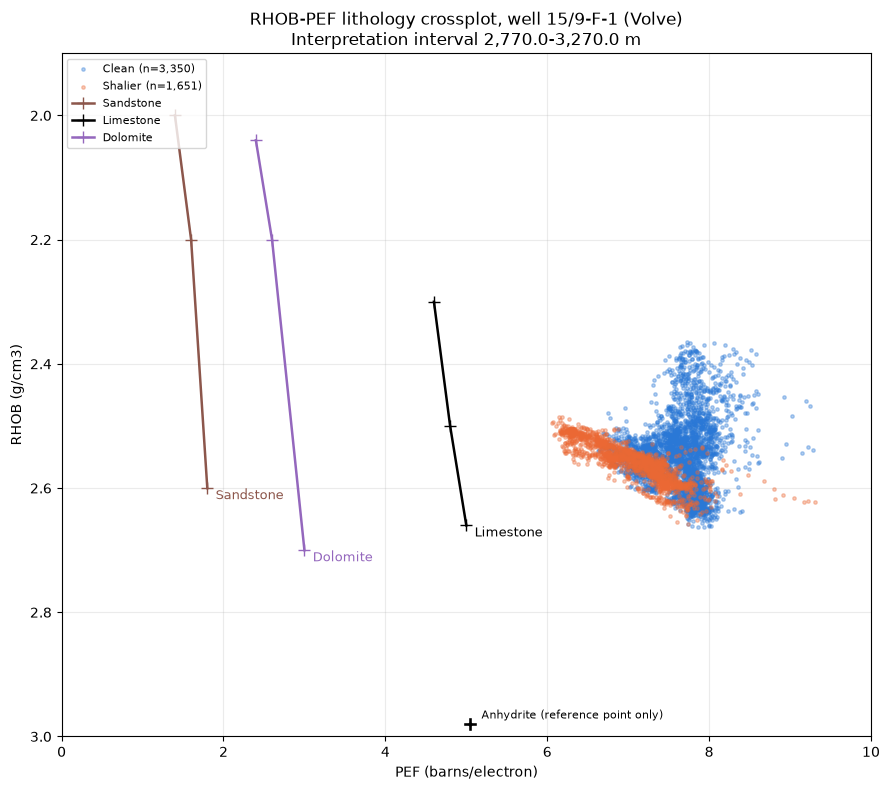

PEF range in interval: 6.06 - 9.31 b/e
PEF median: 7.55 b/e
RHOB range in interval: 2.365 - 2.662 g/cm3

Highest PEF value covered by each mineral's own verified points (upper end of its line):
  Sandstone: max verified PEF = 1.8, rows with PEF beyond it = 100.0%
  Limestone: max verified PEF = 5.0, rows with PEF beyond it = 100.0%
  Dolomite: max verified PEF = 3.0, rows with PEF beyond it = 100.0%
Saved images/rhob_pef_lithology_crossplot.png


In [50]:
# Cell 54: RHOB-PEF lithology crossplot, mineral lines from verified 3-point tables

pef_by_row = qc_output.loc[
    (qc_output["DEPTH"] >= INTERPRETATION_TOP_M) & (qc_output["DEPTH"] <= INTERPRETATION_BASE_M),
    ["DEPTH", "PEF"],
].reset_index(drop=True)

crossplot_df = interpretation_interval_df[["DEPTH", "RHOB", "ZONE_CHARACTER"]].merge(
    pef_by_row, on="DEPTH", how="left"
)

PEF_MINERAL_POINTS = {
    "Sandstone": ([1.8, 1.6, 1.4], [2.60, 2.20, 2.00], "tab:brown"),
    "Limestone": ([5.0, 4.8, 4.6], [2.66, 2.50, 2.30], "black"),
    "Dolomite": ([3.0, 2.6, 2.4], [2.70, 2.20, 2.04], "tab:purple"),
}

fig, ax = plt.subplots(figsize=(9, 8), facecolor="white")
ax.set_facecolor("white")

clean_pts = crossplot_df.loc[crossplot_df["ZONE_CHARACTER"] == "Clean"]
shalier_pts = crossplot_df.loc[crossplot_df["ZONE_CHARACTER"] == "Shalier"]

ax.scatter(clean_pts["PEF"], clean_pts["RHOB"], s=6, alpha=0.35, color=CLEAN_COLOR,
           label=f"Clean (n={len(clean_pts):,})", zorder=2)
ax.scatter(shalier_pts["PEF"], shalier_pts["RHOB"], s=6, alpha=0.35, color=SHALIER_COLOR,
           label=f"Shalier (n={len(shalier_pts):,})", zorder=2)

for name, (pef_pts, rhob_pts, line_color) in PEF_MINERAL_POINTS.items():
    ax.plot(pef_pts, rhob_pts, color=line_color, linewidth=1.8, marker="+", markersize=9, zorder=4, label=name)
    ax.annotate(name, (pef_pts[0], rhob_pts[0]), textcoords="offset points",
                xytext=(6, -8), fontsize=9, color=line_color, zorder=5)

# Anhydrite: single zero-porosity reference point only - no verified table to draw a line
ax.scatter(5.05, 2.98, s=110, marker="P", color="black", edgecolor="white", linewidth=1.0, zorder=6)
ax.annotate("Anhydrite (reference point only)", (5.05, 2.98), textcoords="offset points",
            xytext=(8, 4), fontsize=8, zorder=6)

ax.set_xlim(0, 10)
ax.set_ylim(3.0, 1.9)
ax.set_xlabel("PEF (barns/electron)")
ax.set_ylabel("RHOB (g/cm3)")
ax.set_title("RHOB-PEF lithology crossplot, well 15/9-F-1 (Volve)\nInterpretation interval 2,770.0-3,270.0 m")
ax.grid(alpha=0.25)
ax.set_axisbelow(True)
ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "rhob_pef_lithology_crossplot.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

print(f"PEF range in interval: {crossplot_df['PEF'].min():.2f} - {crossplot_df['PEF'].max():.2f} b/e")
print(f"PEF median: {crossplot_df['PEF'].median():.2f} b/e")
print(f"RHOB range in interval: {crossplot_df['RHOB'].min():.3f} - {crossplot_df['RHOB'].max():.3f} g/cm3")
print()
print("Highest PEF value covered by each mineral's own verified points (upper end of its line):")
for name, (pef_pts, rhob_pts, _) in PEF_MINERAL_POINTS.items():
    max_pef = max(pef_pts)
    pct_beyond = (crossplot_df["PEF"] > max_pef).mean() * 100
    print(f"  {name}: max verified PEF = {max_pef}, rows with PEF beyond it = {pct_beyond:.1f}%")
print("Saved images/rhob_pef_lithology_crossplot.png")


**Reading the crossplot:** all 5,001 rows sit to the right of all three mineral lines on
the PEF axis, across their entire verified porosity range, not just at zero porosity - even
Limestone's highest-PEF point (5.0, its lowest-porosity end) is exceeded by effectively the
whole dataset, and Dolomite (max 3.0) and Sandstone (max 1.8) are exceeded even more
completely. The minimum PEF in the interval (6.06 b/e) already sits beyond every point on
every mineral line. Vertically, RHOB (2.365-2.662 g/cm3) sits mostly below the quartz and
limestone lines' low-porosity ends, which is the expected, unremarkable signature of ordinary
effective porosity in the rock rather than anything unusual.

This is the same PEF evidence discussed in Step 9, now shown directly against real
porosity-spanning mineral lines rather than just zero-porosity points or a summary statistic:
a median PEF of 7.55 b/e is off the low end of even Limestone's own verified range, and the
gap holds across the whole dataset, not just at one endpoint. This rules out clean quartz and
clean calcite alike, but it does not mathematically single out 2.65, 2.68, or any other
specific density as more correct than the others - a two-endmember quartz-calcite mixture
cannot even reach this well's observed PEF, since 7.55 exceeds the calcite endpoint (~5.1)
itself.

This does not mean the rock is not sandstone. Sodir's own Hugin Formation description states
plainly that "the sandstones are often calcareous and glauconitic" - both calcite cement and
glauconite (an iron-rich clay mineral) push PEF well above pure quartz's ~1.8, and calcite
alone can approach or exceed its own ~5.1 endpoint. A calcareous, glauconitic sandstone -
exactly Hugin's documented regional character - would be expected to sit off the pure-quartz
line without being a different rock at all. What this crossplot actually shows is that the
matrix is not pure quartz - consistent with either a calcareous/glauconitic sandstone or a
different lithology entirely. This well has no confirmed formation tops, so the log data
alone cannot settle which.

#### Density-neutron crossplot (classic chart layout)

This recreates the standard density-neutron crossplot layout (as in Glover's Petrophysics
course notes, Fig. 15.14, and equivalent charts in Rider, Asquith, and Schlumberger
chartbooks) - **RHOB on the y-axis (1.9-3.0 g/cm3) against apparent limestone porosity on the
x-axis** - then overlays this well's own NPHI/RHOB data.

**The three mineral lines use verified points read directly from the original reference
chart** (3 points per mineral, apparent limestone porosity vs RHOB):

| Apparent LS porosity (pu) | Dolomite RHOB | Limestone RHOB | Sandstone RHOB |
|---|---|---|---|
| 0 | 2.86 | 2.70 | 2.62 |
| 20 | 2.54 | 2.36 | 2.22 |
| 35 | 2.28 | 2.15 | 1.99 |

A quadratic is fit exactly through each mineral's 3 points (3 points uniquely determine a
quadratic, so the fitted curve passes through all 3 exactly - no smoothing or approximation
error). This is a real improvement on an earlier version of this chart, which only had 2
verified points per mineral (0% and 10%) and so could only support a straight line; 3 points
support genuine curvature. Each curve is plotted only across 0-35 pu - the span the verified
points actually cover - rather than extrapolated beyond it. Limestone comes out
correctly close to a straight line here too (fitted curvature coefficient ~0.00009, negligible
over this range) - consistent with it being the exact calibration lithology, not a
coincidence.

Anhydrite remains a single reference point only (RHOB 2.98, apparent porosity ~0) - still no
verified multi-point table for it, so still no line.

**This version plots only `SAND_FLAG` rows** (3,616 of 5,001, VSH <= 0.5) instead of the full
interpretation interval, to see whether restricting to the already-cleaner subset changes
which mineral line the data sits closest to. A second y-axis (density porosity, assuming a
limestone matrix of 2.71 g/cm3) is added on the right, matching the reference chart's
convention.

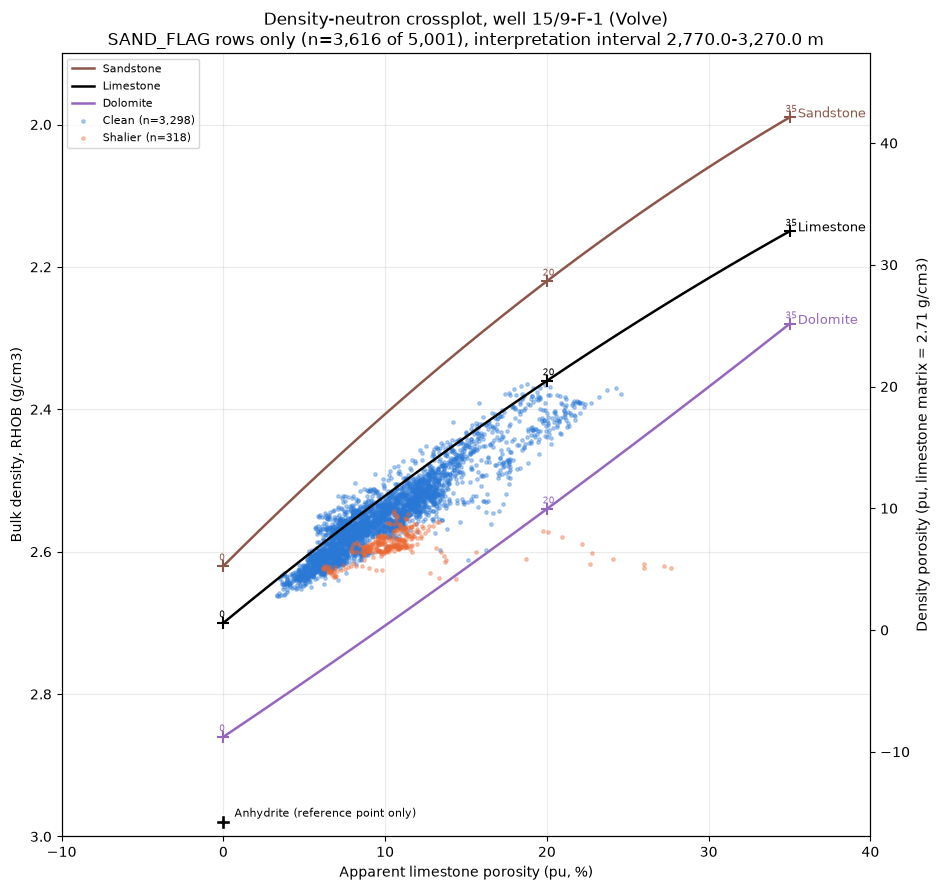

SAND_FLAG rows plotted: 3,616 of 5,001
  Clean: 3,298, Shalier: 318

Fitted quadratic coefficients (a, b, c) for RHOB = a*x^2 + b*x + c, x = apparent LS porosity (pu):
  Sandstone: [ 1.33333333e-04 -2.26666667e-02  2.62000000e+00]
  Limestone: [ 8.57142857e-05 -1.87142857e-02  2.70000000e+00]
  Dolomite: [-3.80952381e-05 -1.52380952e-02  2.86000000e+00]

Mean residual (actual RHOB - mineral-curve-predicted RHOB at that row's own measured NPHI), SAND_FLAG rows only:
  Clean:
    Sandstone: mean residual=+0.1399 g/cm3, mean |residual|=0.1399 g/cm3
    Limestone: mean residual=+0.0260 g/cm3, mean |residual|=0.0289 g/cm3
    Dolomite: mean residual=-0.1546 g/cm3, mean |residual|=0.1546 g/cm3
  Shalier:
    Sandstone: mean residual=+0.1937 g/cm3, mean |residual|=0.1937 g/cm3
    Limestone: mean residual=+0.0778 g/cm3, mean |residual|=0.0778 g/cm3
    Dolomite: mean residual=-0.1040 g/cm3, mean |residual|=0.1128 g/cm3
  Whole SAND_FLAG subset:
    Sandstone: mean residual=+0.1446 g/cm3, mean

In [51]:
# Cell 55: Density-neutron crossplot, fit through verified 3-point tables, SAND_FLAG rows only

ND_MINERAL_POINTS = {
    "Sandstone": ([0, 20, 35], [2.62, 2.22, 1.99], "tab:brown"),
    "Limestone": ([0, 20, 35], [2.70, 2.36, 2.15], "black"),
    "Dolomite": ([0, 20, 35], [2.86, 2.54, 2.28], "tab:purple"),
}

ND_MINERAL_COEFFS = {
    name: np.polyfit(x_pts, y_pts, 2) for name, (x_pts, y_pts, _) in ND_MINERAL_POINTS.items()
}

fig, ax = plt.subplots(figsize=(9.5, 9), facecolor="white")
ax.set_facecolor("white")

x_line = np.linspace(0, 35, 200)

for name, (x_pts, y_pts, line_color) in ND_MINERAL_POINTS.items():
    coeffs = ND_MINERAL_COEFFS[name]
    y_line = np.polyval(coeffs, x_line)
    ax.plot(x_line, y_line, color=line_color, linewidth=1.8, label=name, zorder=4)
    ax.annotate(name, (x_line[-1], y_line[-1]), textcoords="offset points",
                xytext=(6, 0), fontsize=9, color=line_color, zorder=5)

    # The verified points themselves, marked explicitly
    ax.scatter(x_pts, y_pts, marker="+", s=70, color=line_color, zorder=6)
    for xp, yp in zip(x_pts, y_pts):
        ax.annotate(f"{xp}", (xp, yp), textcoords="offset points",
                    xytext=(-3, 4), fontsize=6.5, color=line_color, zorder=5)

# Anhydrite: single reference point only - no verified table to fit a line
ax.scatter(0, 2.98, s=110, marker="P", color="black", edgecolor="white", linewidth=1.0, zorder=6)
ax.annotate("Anhydrite (reference point only)", (0, 2.98), textcoords="offset points",
            xytext=(8, 4), fontsize=8, zorder=6)

sand_flag_df = interpretation_interval_df.loc[interpretation_interval_df["SAND_FLAG"]]

clean_pts = sand_flag_df.loc[sand_flag_df["ZONE_CHARACTER"] == "Clean"]
shalier_pts = sand_flag_df.loc[sand_flag_df["ZONE_CHARACTER"] == "Shalier"]

ax.scatter(clean_pts["NPHI"] * 100, clean_pts["RHOB"], s=6, alpha=0.35, color=CLEAN_COLOR,
           label=f"Clean (n={len(clean_pts):,})", zorder=2)
ax.scatter(shalier_pts["NPHI"] * 100, shalier_pts["RHOB"], s=6, alpha=0.35, color=SHALIER_COLOR,
           label=f"Shalier (n={len(shalier_pts):,})", zorder=2)

ax.set_xlim(-10, 40)
ax.set_ylim(3.0, 1.9)
ax.set_xlabel("Apparent limestone porosity (pu, %)")
ax.set_ylabel("Bulk density, RHOB (g/cm3)")
ax.set_title(
    f"Density-neutron crossplot, well 15/9-F-1 (Volve)\n"
    f"SAND_FLAG rows only (n={len(sand_flag_df):,} of {len(interpretation_interval_df):,}), "
    f"interpretation interval 2,770.0-3,270.0 m"
)
ax.grid(alpha=0.25)
ax.set_axisbelow(True)
ax.legend(fontsize=8, loc="upper left")

# Second y-axis: density porosity, assuming a limestone matrix (2.71 g/cm3), matching the
# reference chart's convention.
LIMESTONE_MATRIX_DENSITY = 2.71
ax2 = ax.twinx()
ax2.set_ylim(
    (LIMESTONE_MATRIX_DENSITY - 3.0) / (LIMESTONE_MATRIX_DENSITY - 1.0) * 100,
    (LIMESTONE_MATRIX_DENSITY - 1.9) / (LIMESTONE_MATRIX_DENSITY - 1.0) * 100,
)
ax2.set_ylabel("Density porosity (pu, limestone matrix = 2.71 g/cm3)")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "neutron_density_lithology_chart.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

print(f"SAND_FLAG rows plotted: {len(sand_flag_df):,} of {len(interpretation_interval_df):,}")
print(f"  Clean: {len(clean_pts):,}, Shalier: {len(shalier_pts):,}")
print()
print("Fitted quadratic coefficients (a, b, c) for RHOB = a*x^2 + b*x + c, x = apparent LS porosity (pu):")
for name, coeffs in ND_MINERAL_COEFFS.items():
    print(f"  {name}: {coeffs}")

print()
print("Mean residual (actual RHOB - mineral-curve-predicted RHOB at that row's own measured NPHI), SAND_FLAG rows only:")
for zone_name, zone_df in [("Clean", clean_pts), ("Shalier", shalier_pts), ("Whole SAND_FLAG subset", sand_flag_df)]:
    print(f"  {zone_name}:")
    nphi_pct = zone_df["NPHI"] * 100
    for name, coeffs in ND_MINERAL_COEFFS.items():
        predicted_rhob = np.polyval(coeffs, nphi_pct)
        resid = zone_df["RHOB"] - predicted_rhob
        print(f"    {name}: mean residual={resid.mean():+.4f} g/cm3, mean |residual|={resid.abs().mean():.4f} g/cm3")

print("Saved images/neutron_density_lithology_chart.png")


**Reading the density-neutron crossplot (SAND_FLAG rows only):** the data does not match
a pure-quartz sandstone response - actual RHOB sits roughly 0.14-0.19 g/cm3 above what the
Sandstone reference curve predicts at the same measured NPHI, in both zones - a large,
one-directional, consistent miss, not noise. This does not rule out sandstone as a rock type:
Sodir's own description of the Hugin Formation - Volve's regional reservoir - states the
sandstones are "often calcareous and glauconitic," and both features would shift a real
sandstone's log response away from the pure-quartz line without changing what the rock
fundamentally is. What this chart shows is a non-pure-quartz response, not a different
lithology confirmed.

**The Clean zone still clusters closest to the Limestone line**, and the fit is about the
same as before, not tighter or looser: mean absolute residual 0.029 g/cm3 here versus 0.030
g/cm3 in the unfiltered 5,001-row version - a negligible difference. Restricting to
`SAND_FLAG` rows drops only 52 Clean-zone rows (3,350 to 3,298), essentially all of which
were already close to the Limestone line, so the filter barely moves this number. This is
consistent with a calcareous sandstone (calcite cement pulling the response toward the
Limestone line) as much as with a true limestone matrix - the two are not distinguishable
from this chart alone. Dolomite is a clearly worse fit for the Clean zone (mean absolute
residual 0.155 g/cm3). In the Shalier subset, Limestone also gives the smaller mean absolute
residual: approximately 0.078 g/cm3 compared with 0.113 g/cm3 for Dolomite. However, shale
effects and uncertain neutron calibration mean that this should not be treated as definitive
lithology identification.

Several related log diagnostics show the same broad response: the clean-zone measurements do
not follow a simple pure-quartz reference trend and plot closer to the Limestone reference
trend. These diagnostics share density-tool measurements and assumptions, so they are
supporting observations rather than fully independent evidence.

The response is consistent with a calcareous or glauconitic sandstone, which matches the
published regional description of the Hugin Formation, but the available logs alone cannot
determine the matrix mineralogy conclusively.

## References

- **Glover, P.** - Petrophysics course notes (neutron-density crossplot theory and classic
  chart layout, Figs. 14.3, 14.6, 15.14).
- **Humble formula** - the `a = 0.62`, `m = 2.15` cementation-exponent pair used in Archie's
  equation for sandstone (Winsauer et al., 1952).
- **Simandoux, P.** (1963) - the shaly-sand saturation model used in the Shalier zone.
- **Sodir (Norwegian Offshore Directorate)** - Hugin Formation stratigraphy and lithology
  description ("often calcareous and glauconitic" sandstone), used to interpret this well's
  non-pure-quartz log response. This citation was not independently web-verified within this
  project.